# Analysis of Household Energy Consumption and Socio-Economic Equity in Germany

**Author: Maximilian Starp**

**E-Mail: maximilian@starp.email**

### Executive Summary
This project analyzes the shifts in energy consumption patterns within German households over the past decades. The primary focus lies on the structural political, economic and with that socio-economic transition from fossil fuels toward renewable energy sources and the resulting impact on the household energy mix.

### Research Questions
To what extent is the transition from fossil to renewable energy affecting socio-economic equity? Specifically, this Datapipeline investigates whether the financial burden of climate change mitigation is being disproportionately carried by lower-income populations (energy poverty).

## Methodology & Core Assumptions

A statistical model is an approximation of reality. While it cannot capture every individual household's circumstances, this model tries to reflect the most accurate trends possible based on standardized benchmarks. To ensure consistency across the 30-year timeframe and various data sources, the following core assumptions are applied:

1. **Standardized Household Profile**
To calculate the "Energy Burden" consistently, a representative household based on German average benchmarks must be defined:
- Household Size: 3 persons (Standard family unit).
- Living Space: 70 m² of floor area.
- Heating Demand: 120 kWh/m² per year (Reflecting average thermal efficiency standards for residential buildings).
- Electricity Consumption: 4,000 kWh per household/year (Aligned with Eurostat residential standards).

**Sources for these assumptions**:
- Household size: https://www.umweltbundesamt.de/daten/private-haushalte-konsum/strukturdaten-privater-haushalte/bevoelkerungsentwicklung-struktur-privater#836-millionen-menschen​
- Living Space: https://www.buergergeld.org/news/buergergeld-so-hoch-darf-miete-wohnung-sein/​
- Heating-Demand: https://www.adac.de/rund-ums-haus/energie/spartipps/heizkosten-haushalt/​
- Electricity Consumption: https://www.adac.de/rund-ums-haus/energie/spartipps/stromverbrauch-im-haushalt/

2. **Consumption vs. Income (Conservative Estimate)**
This model applies the same average energy consumption across all income deciles.
- Critical Note: In reality, lower-income households often live in less energy-efficient housing or use older appliances. By using a fixed average consumption, this model likely provides a conservative estimate of energy poverty, the actual financial burden on the lowest 10% may be even higher.

3. **Unit Normalization**
To ensure comparability between different energy carriers and historical data:
- All energy data is converted to a consistent unit (kWh).
- For historical gas data reported in Gigajoules (GJ), the standard physical conversion factor of $1 GJ \approx 277.78 kWh$ is applied.

4. **Nominal Comparison**
- Since this study compares energy costs directly against income within the same calendar year (Energy Burden Ratio), the analysis is performed using nominal values. This accurately reflects the immediate financial pressure on households, as inflation affects both prices and incomes simultaneously in the ratio.

In [1]:
# import requirements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.stats import lognorm
from scipy.integrate import quad

## Step 1: Data Acquisition & Loading

In this section, the six core datasets required for the socio-economic impact analysis are imported. These datasets allow a view of energy costs, consumption patterns, and income distribution over a 30-year period.

### Primary Datasets:
- **Household Energy Consumption by Source:** A detailed annual breakdown of energy forms (Electricity, Gas, Renewables, etc.) consumed by German households.
- **Equivalised Disposable Income:** Annual data categorized by income deciles and quantiles.
    - Definition: The Equivalised Disposable Income is the total income of a household after taxes and other deductions, adjusted for household size using the OECD equivalence scale. This metric allows for a fair comparison of living standards across different household types.
- **Electricity & Natural Gas Pricing:** Multi-part datasets covering price evolution for Germany and the EU.
    - Frequency: Data is reported semi-annually (S1 and S2).
    - Timeframes: Split into historical (pre-2007) and modern (post-2007) reporting standards.

### Technical Note: The 2007 Methodological Shift

A significant problem in this analysis might be the 2007 Eurostat reporting change.
- The Issue: Before 2007, prices were based on "standard consumers" (theoretical models). Since 2007, reporting is based on "actual average prices" paid by real households.
- The "Jump": This shift can cause a statistical discontinuity (a "jump") in the time series. While this project harmonizes these datasets by filtering for consistent consumption bands (e.g., Band DC for electricity), this transition remains a critical point of interest.
- Analysis: This potential break is documented here and will be specifically addressed and visualized in the following.

### Data Sources
- `EnergyMix_Households_1990-2024_Germany_annual_KWH.csv`: https://www.umweltbundesamt.de/daten/energie/energieverbrauch-nach-energietraegern-sektoren#allgemeine-entwicklung-und-einflussfaktoren
- `GasPrices_Households_2007-2025_Germany-EU_biannual_KWH.csv`: https://ec.europa.eu/eurostat/databrowser/view/nrg_pc_202/default/table?lang=de&category=nrg.nrg_price.nrg_pc​
- `ElectricityPrices_Households_1991-2007_Germany-EU_biannual_KWH.csv`: https://ec.europa.eu/eurostat/databrowser/view/nrg_pc_204_h__custom_19552756/default/table​
- `ElectricityPrices_Households_2007-2025_Germany-EU_biannual_KWH.csv`: https://ec.europa.eu/eurostat/databrowser/view/nrg_pc_204/default/table?lang=de&category=nrg.nrg_price.nrg_pc​
- `GasPrices_Households_1985-2007_Germany-EU_biannual_GJ.csv`: https://ec.europa.eu/eurostat/databrowser/view/nrg_pc_202_h/default/table?lang=de&category=nrg.nrg_price.nrg_pc_h​

In [2]:
# --- Load the Datasets ---

data_files = {
    "energy_mix": "EnergyMix_Households_1990-2024_Germany_annual_KWH.csv",
    "income": "EquivalisedIncome_PerCapita_1995-2025_Germany_EU_annual_EUR.csv",
    "elec_prices_old": "ElectricityPrices_Households_1991-2007_Germany-EU_biannual_KWH.csv",
    "elec_prices_new": "ElectricityPrices_Households_2007-2025_Germany-EU_biannual_KWH.csv",
    "gas_prices_old": "GasPrices_Households_1985-2007_Germany-EU_biannual_GJ.csv",
    "gas_prices_new": "GasPrices_Households_2007-2025_Germany-EU_biannual_KWH.csv",
}

datasets = {}

for key, file in data_files.items():
    try:
        datasets[key] = pd.read_csv(f"./data/{file}")
        print(f"Successfully loaded {key}")
    except FileNotFoundError:
        print(f"Error: {file} not found in directory.")

Successfully loaded energy_mix
Successfully loaded income
Successfully loaded elec_prices_old
Successfully loaded elec_prices_new
Successfully loaded gas_prices_old
Successfully loaded gas_prices_new


## Step 2: Data Harmonization Pipeline (1995–2024)

This section implements the core data processing pipeline. It integrates the four disparate data streams: Energy Mix (Consumption), Electricity Prices, Gas Prices, and Equivalised Income. The pipeline performs unit normalization, handles the 2007 Eurostat methodological shift, and transforms the data from long to wide format for time-series analysis.

### 1. Global Parameters & Temporal Alignment
- **Timeframe:** Data is strictly filtered to the range 1995–2024, representing the maximum period of overlap across all datasets. 
- **Temporal Aggregation (`get_clean_year`):** Eurostat reports semi-annual data (e.g., "2007-S1"). This function extracts the calendar year and calculates the annual arithmetic mean of both semesters to provide a stable yearly value.

### 2. Electricity & Gas Price Harmonization (process_prices)
Processing energy prices is complex due to the 2007 reporting change. The pipeline addresses this through:

- **Methodology Stitching**
  To maintain a continuous time series, data prior to 2007 is sourced from the "Old" methodology datasets, while data from 2007 onwards is pulled from the "New" datasets. 2007 serves as the transition year to ensure the most modern reporting standards are prioritized.

- **Gas Unit Normalization**
  Historical gas prices (reported in Gigajoules - GJ) are normalized to the modern kWh standard by dividing by 277.78.

- **Consumption Band Filtering**
  To ensure the price data is representative of a standard household and to avoid duplicates, the script filters for:
  - Electricity: Band DC (Annual consumption: 2,500–5,000 kWh).
  - Gas: Band D2 / D3 (Standard residential heating).

- **Structural Transformation**
  The vertical (long) Eurostat structure is pivoted into side-by-side (wide) columns (e.g., Price_Germany_WithTaxes_perKWh). This enables a direct comparison of tax burdens and price dynamics between Germany and the EU average.

### 3. Income Data Transformation

- **Objective:** Convert vertical income quantiles into a horizontal threshold table.
  - Pivot Table: The script transforms the quantile column so that each income decile (e.g., Income_Germany_First_decile) becomes an individual feature for each year.
  - Metric: Uses the equivalised disposable income (Top cut-off point) to represent the financial ceiling of different socio-economic groups.

### 5. Final Output Structure

The pipeline yields region-specific DataFrames (GER and EU) for electricity, gas, and income. These clean datasets serve as the foundation for the subsequent Energy Burden and Correlation Analysis.

The final output structure is:
- `df_energy_final` (by nature only data from Germany)
- `df_elec_GER`
- `df_elec_EU`
- `df_gas_GER`
- `df_gas_EU`
- `df_income_GER`
- `df_income_EU`


In [3]:
START_YEAR = 1995
END_YEAR = 2024

# --- 1. Helper Functions ---
def get_clean_year(df):
    if 'TIME_PERIOD' in df.columns:
        return df['TIME_PERIOD'].astype(str).str[:4].astype(int)
    return df['Year']

def process_prices(df_old_raw, df_new_raw, is_gas=False):
    df_old = df_old_raw.copy()
    df_new = df_new_raw.copy()
    
    # Standardize Years
    df_old['Year'] = get_clean_year(df_old)
    df_new['Year'] = get_clean_year(df_new)
    
    # IMPORTANT: Filter for the standard household consumption band to avoid duplicates
    # Electricity: Band DC (2500-5000 kWh) | Gas: Band D2 (20-200 GJ)
    if is_gas:
        # Filter for the standard band in both old and new formats
        df_old = df_old[df_old['consom'].str.contains('D3', na=False)] 
        df_new = df_new[df_new['nrg_cons'].str.contains('D2', na=False)]
    else:
        df_old = df_old[df_old['consom'].str.contains('Dc', na=False)]
        df_new = df_new[df_new['nrg_cons'].str.contains('DC', na=False)]

    # 2007 Priority Logic: Remove 2007 from old, keep in new
    df_old = df_old[df_old['Year'] < 2007]
    
    # Reset index before concatenation to avoid "duplicate labels" error
    combined = pd.concat([df_old, df_new], ignore_index=True, sort=False)
    
    # Unit conversion for Gas (GJ -> KWh)
    if is_gas:
        # Apply conversion only to rows where the unit was Gigajoule (the old data)
        mask_old = combined['Year'] < 2007
        combined.loc[mask_old, 'OBS_VALUE'] = combined.loc[mask_old, 'OBS_VALUE'] / 277.78
    
    # Filter timeframe
    combined = combined[(combined['Year'] >= START_YEAR) & (combined['Year'] <= END_YEAR)]
    
    # Create clean Metric names for pivoting
    combined['Country'] = np.where(combined['geo'].str.contains('Germany'), 'Germany', 'EU')
    combined['Tax_Status'] = np.where(combined['tax'].str.contains('Excluding'), 'WithoutTaxes', 'WithTaxes')
    
    # Group by Year, Country, Tax_Status and average the semesters (S1, S2)
    final = combined.groupby(['Year', 'Country', 'Tax_Status'])['OBS_VALUE'].mean().unstack(level=[1, 2])
    
    # Flatten column names: e.g., "Price_Germany_WithTaxes_perKWh"
    prefix = "Gas" if is_gas else "Elec"
    final.columns = [f"{prefix}_{country}_{tax}_perKWh" for country, tax in final.columns]
    
    return final.reset_index()

# --- 2. Run Processing ---

# Energy Mix
df_mix = datasets["energy_mix"].copy()
df_mix['Year'] = get_clean_year(df_mix)
energy_cols = ['Mineral Oils', 'Gases', 'Electricity', 'District Heating', 
               'Coal', 'Renewable Energies', 'Other Energy Sources', 'All Energy Sources']
for col in energy_cols:
    if col in df_mix.columns:
        df_mix[col] = df_mix[col].astype(float) * 1_000_000_000 # TWh to KWh
df_energy_final = df_mix[(df_mix['Year'] >= START_YEAR) & (df_mix['Year'] <= END_YEAR)].reset_index(drop=True)

# Prices
df_elec_final = process_prices(datasets["elec_prices_old"], datasets["elec_prices_new"], is_gas=False)
df_gas_final = process_prices(datasets["gas_prices_old"], datasets["gas_prices_new"], is_gas=True)

# Income
df_inc = datasets["income"].copy()
df_inc['Year'] = get_clean_year(df_inc)
df_inc = df_inc[(df_inc['Year'] >= START_YEAR) & (df_inc['Year'] <= END_YEAR)]

# Clean income geography names
df_inc['geo_short'] = np.where(df_inc['geo'] == 'Germany', 'Germany', 'EU')

# Pivot Deciles
df_income_final = df_inc.pivot_table(
    index='Year', 
    columns=['geo_short', 'quantile'], 
    values='OBS_VALUE',
    aggfunc='mean' # In case of duplicate reporting
)
df_income_final.columns = [f"Income_{geo}_{q.replace(' ', '_')}" for geo, q in df_income_final.columns]
df_income_final = df_income_final.reset_index()

# --- 3. Split into Europe and Germany Dataframes ---
def split_by_region(df, region_name):
    """
    Keeps 'Year' and any column containing the specific region name.
    """
    cols_to_keep = ['Year'] + [col for col in df.columns if region_name in col]
    return df[cols_to_keep].copy()

# Split Electricity Prices
df_elec_GER = split_by_region(df_elec_final, "Germany")
df_elec_EU  = split_by_region(df_elec_final, "EU")

# Split Gas Prices
df_gas_GER = split_by_region(df_gas_final, "Germany")
df_gas_EU  = split_by_region(df_gas_final, "EU")

# Split Income Data
df_income_GER = split_by_region(df_income_final, "Germany")
df_income_EU  = split_by_region(df_income_final, "EU")

## Step 3: Visualization of the Energy Mix (German Households)

To analyze the impact of the energy transition on socio-economic equity, a baseline of the structural shifts in household energy consumption must first be established. If the "Green Transition" is to be blamed for rising costs, it must first be verified that a significant shift toward renewable sources has actually occurred.

**1. Data Preparation:** To visualize these trends, the relative share of renewable energies compared to the total energy consumption for each year is calculated.

**2. Visualization & Trends**  
The transition process from 1995 to 2024 is illustrated in the plots below.
- Figure 1 (Total Consumption): Context on the development of the amount of energy consumed by all households in Germany per year is provided.
- Figure 2 (Renewable Share): The progress of the energy transition is directly tracked.

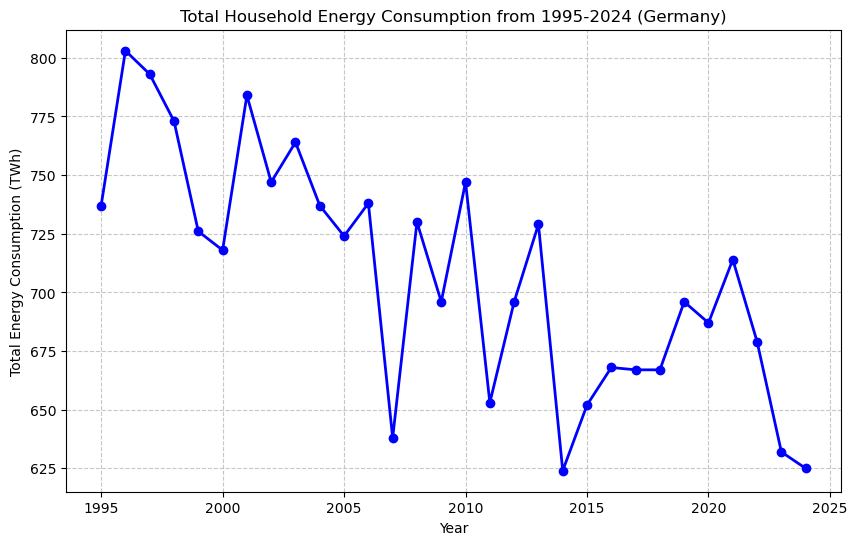

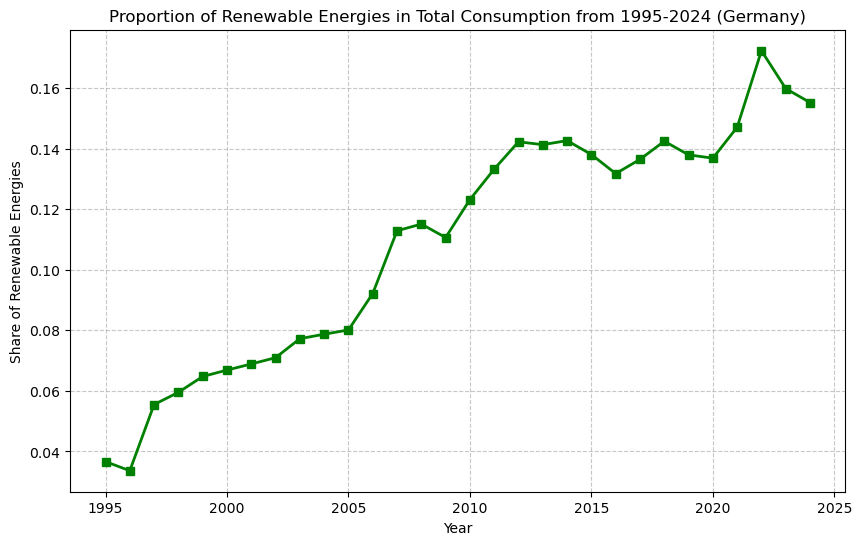

In [4]:
# 2. Calculation for Renewable Share
df_energy_final['Renewable_Share'] = df_energy_final['Renewable Energies'] / df_energy_final['All Energy Sources']

# --- FIGURE 1: Total Energy Consumption ---
plt.figure(figsize=(10, 6))
plt.plot(
    df_energy_final['Year'], 
    df_energy_final['All Energy Sources'] / 1_000_000_000, # Display in TWh
    marker='o', 
    color='blue', 
    linewidth=2
)
plt.xlabel("Year")
plt.ylabel("Total Energy Consumption (TWh)")
plt.title("Total Household Energy Consumption from 1995-2024 (Germany)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Graphs_output/total_energy_consumption.png', dpi=300)

# --- FIGURE 2: Share of Renewable Energies ---
plt.figure(figsize=(10, 6))
plt.plot(
    df_energy_final['Year'], 
    df_energy_final['Renewable_Share'], 
    marker='s', 
    color='green', 
    linewidth=2
)
plt.xlabel("Year")
plt.ylabel("Share of Renewable Energies")
plt.title("Proportion of Renewable Energies in Total Consumption from 1995-2024 (Germany)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Graphs_output/renewable_share.png', dpi=300)

## Step 3.1: Analysis of Consumption Trends

The visualizations highlight two central developments in German household energy consumption between 1995 and 2024.

### 1. Efficiency Gains and Reduced Demand

A gradual decline in total household energy consumption can be observed over the examined period. Consumption decreased from approximately **750 TWh (terawatt-hours)** in 1995 to roughly **650 TWh** in 2024.

- **Interpretation:**  
  This overall reduction of about $\approx 13\%$ indicates significant improvements in energy efficiency within the residential sector. Several structural factors are likely responsible, including stricter building regulations (e.g., the *Energieeinsparverordnung – EnEV*), the modernization of heating systems, and the widespread adoption of energy-efficient household appliances.

### 2. The Rise of Renewables

At the same time, the share of renewable energy sources in total household energy consumption increased markedly—from approximately **4% in 1995** to about **16% in 2024**.

- **Interpretation:**  
  This increase reflects substantial progress in the German *Energiewende* within the residential sector. Key drivers include the expansion of biomass-based heating (e.g., wood pellets), the growing use of solar thermal systems, and the increasing role of green electricity and heat pumps in household energy supply.

- **Relevance for Research:**  
  This structural transformation provides the foundation for the central research question of this study: **As households transition toward these new energy sources, how are the associated costs—such as taxes, levies, and required investments—distributed across different income deciles?**

## Step 4: Modeling the Income Distribution (CDF Simulation)

To analyze energy poverty across the entire population—not only at discrete income points—a continuous representation of the income distribution is required. This step therefore fits a **lognormal cumulative distribution function (CDF)** to the observed Eurostat income data for each year.

### 1. Mathematical Approach: The Lognormal Distribution

The lognormal CDF is defined by two key parameters:

- **μ (Mu):** The *scale parameter*, most of the time closely related to the **median income** of the distribution.  
- **σ (Sigma):** The *shape parameter*, representing the **degree of income inequality** (i.e., the spread of the distribution).

Together, these parameters describe the full income distribution of the population.

### 2. The Fitting Process (*fit_regional_income*)

For each year in the dataset, the script performs a **non-linear least squares fit** using `curve_fit` in order to estimate the optimal values of μ and σ.

The fitting procedure consists of three main steps:

- **Data Mapping:**  
  Eurostat income categories (e.g., *First Decile*, *Second Decile*) are mapped to their corresponding **cumulative probabilities** (e.g., 0.1, 0.2, …).

- **Optimization:**  
  The algorithm minimizes the **Mean Squared Error (MSE)** between the theoretical lognormal CDF and the observed income thresholds reported in the Eurostat data.

- **Dynamic Scaling:**  
  Because income levels change significantly over the 30-year observation period, the fitting routine dynamically estimates an initial parameter guess (`p0`) based on the **median income of the respective year**, ensuring stable and reliable convergence.

### 3. Output: Distribution Parameters

The result of this process is a **time series of μ and σ parameters** for both **Germany** and the **European Union**.

These estimated parameters enable several important analytical steps:

- Reconstruction of the **complete income distribution** for any given year.  
- Estimation of the **share of households exceeding a given cost threshold**, such as spending more than **10% of their income on energy**.  
- Comparison of **inequality dynamics** across time and regions.

### Visualization

To illustrate the quality of the fit and the resulting distributions, several **example plots of the fitted CDF curves** are generated.

In [5]:
def lognorm_cdf(x, sigma, scale):
    """The standard Log-Normal CDF function."""
    return lognorm.cdf(x, sigma, scale=scale)

PROB_MAP = {
    'First_percentile': 0.01, 'Second_percentile': 0.02, 'Third_percentile': 0.03, 'Fourth_percentile': 0.04,
    'Fifth_percentile': 0.05, 'Ninety-fifth_percentile': 0.95, 'Ninety-sixth_percentile': 0.96,
    'Ninety-seventh_percentile': 0.97, 'Ninety-eighth_percentile': 0.98, 'Ninety-ninth_percentile': 0.99,
    'First_decile': 0.1, 'Second_decile': 0.2, 'Third_decile': 0.3, 'Fourth_decile': 0.4,
    'Fifth_decile': 0.5, 'Sixth_decile': 0.6, 'Seventh_decile': 0.7, 'Eighth_decile': 0.8, 'Ninth_decile': 0.9,
    'First_quartile': 0.25, 'Second_quartile': 0.5, 'Third_quartile': 0.75,
    'First_quintile': 0.2, 'Second_quintile': 0.4, 'Third_quintile': 0.6, 'Fourth_quintile': 0.8
}

def fit_regional_income(df_input, region_name):
    final_results = []
    
    # Prefix to match columns: e.g., "Income_Germany_" or "Income_EU_"
    prefix = f"Income_{region_name}_"
    income_cols = [c for c in df_input.columns if prefix in c]
    
    for _, row in df_input.iterrows():
        year = row['Year']
        x_vals = []
        y_vals = []
        
        # 1. Filter out NaNs and match column probabilities
        for col in income_cols:
            suffix = col.replace(prefix, "")
            if suffix in PROB_MAP and pd.notnull(row[col]):
                # Ensure the value is a float and above zero (log-normal requirement)
                val = float(row[col])
                if val > 0:
                    x_vals.append(val)
                    y_vals.append(PROB_MAP[suffix])
        
        # 2. Skip the year if we don't have enough data points (need at least 2)
        if len(x_vals) < 3:
            continue 

        # 3. Convert to arrays and Sort
        x_vals = np.array(x_vals)
        y_vals = np.array(y_vals)
        idx = np.argsort(x_vals)
        x_vals, y_vals = x_vals[idx], y_vals[idx]
        
        # 4. Initial Guess (p0)
        # We look for the income value closest to the 50% probability (median)
        median_guess = x_vals[np.argmin(np.abs(y_vals - 0.5))]
        p0 = [0.5, median_guess] 
        
        # 5. Fit the Curve
        # We use a large max_nfev (function evaluations) to help convergence
        popt, _ = curve_fit(lognorm_cdf, x_vals, y_vals, p0=p0, maxfev=2000)
        
        sigma_fit = popt[0]
        mu_fit = np.log(popt[1]) # mu is ln(scale)
        
        # 6. Calculate Fitting Error (MSE)
        error = np.mean((y_vals - lognorm_cdf(x_vals, *popt))**2)
        
        final_results.append({
            'Year': int(year),
            'mu': mu_fit,
            'sigma': sigma_fit,
            # 'fitting_error': error
        })
        
    return pd.DataFrame(final_results)

# Execute
df_params_GER = fit_regional_income(df_income_GER, "Germany")
df_params_EU = fit_regional_income(df_income_EU, "EU")

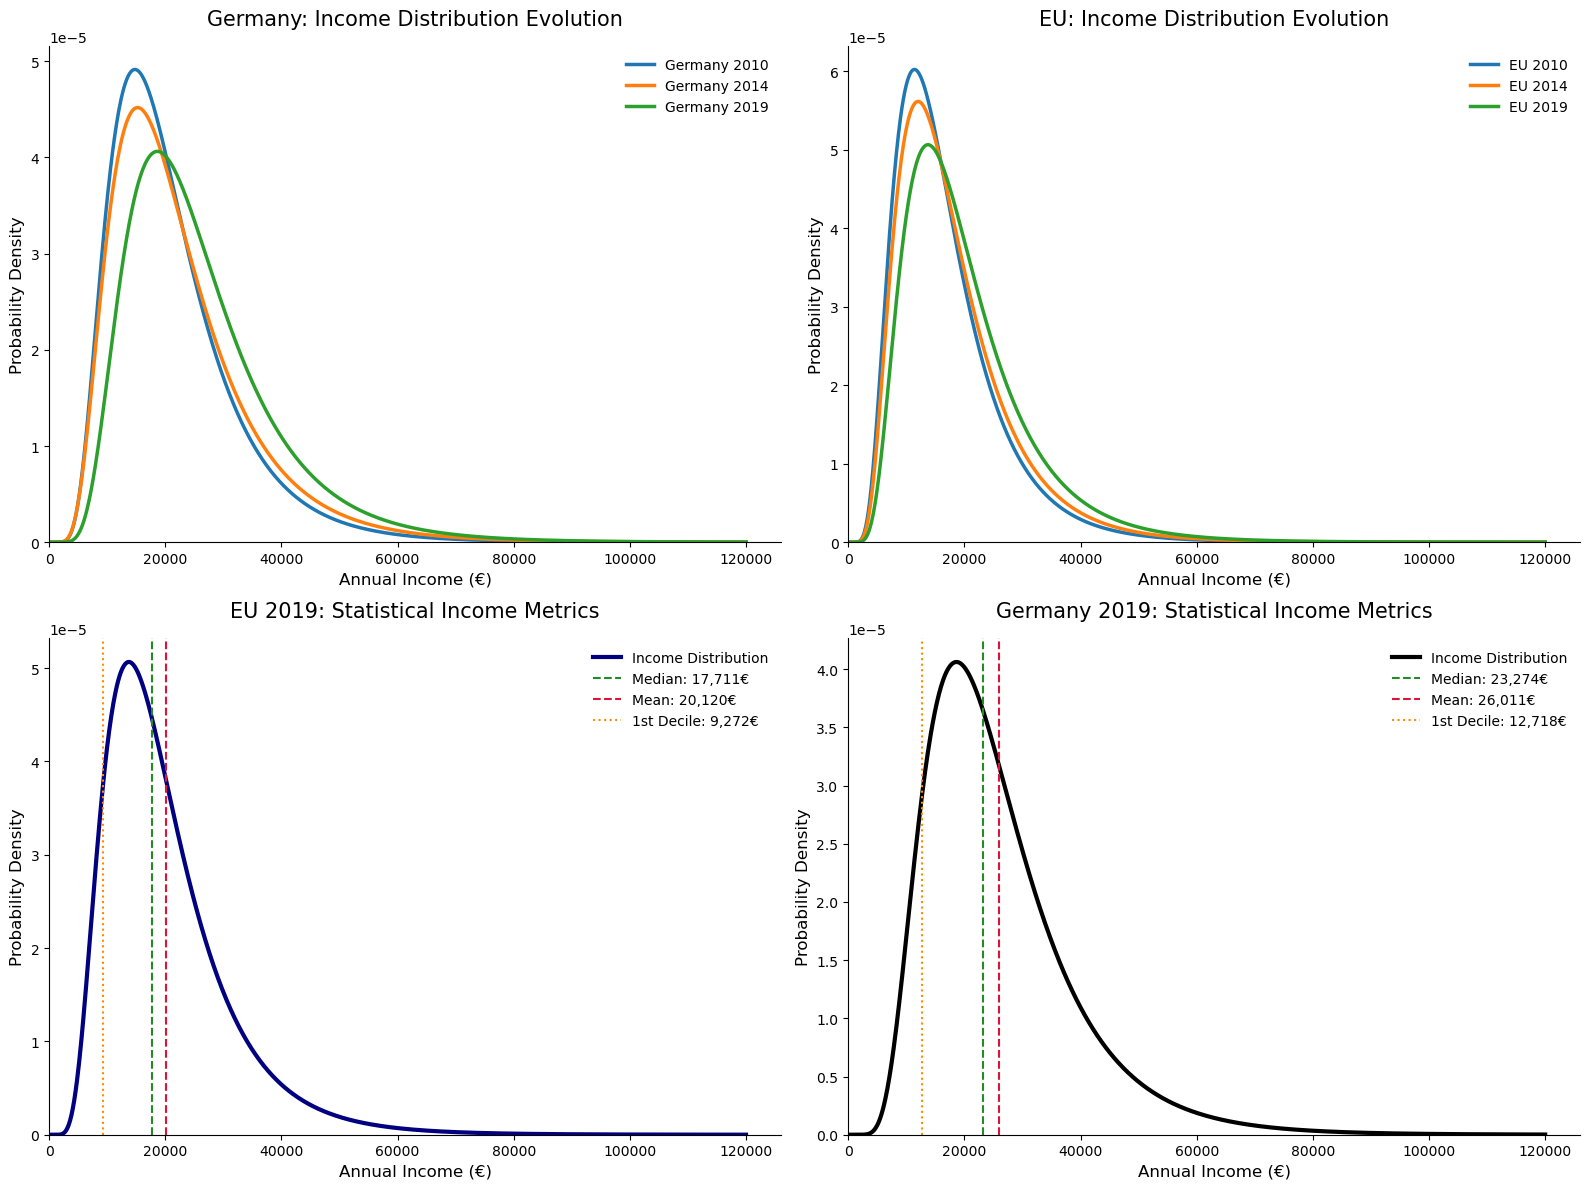

In [6]:
def get_pdf_data(df_params, year, x_range):
    # Retrieve mu and sigma for the specific year
    row = df_params[df_params['Year'] == year].iloc[0]
    mu, sigma = row['mu'], row['sigma']
    
    # Calculate PDF
    pdf = lognorm.pdf(x_range, sigma, scale=np.exp(mu))
    
    # Calculate specific metrics
    median = np.exp(mu)
    mean = np.exp(mu + (sigma**2 / 2))
    first_decile = lognorm.ppf(0.10, sigma, scale=np.exp(mu))
    
    return pdf, median, mean, first_decile

# Range for income axis (starting slightly above 0 to avoid log errors)
x_axis = np.linspace(0.1, 120000, 1000)
years_to_compare = [2010, 2014, 2019]

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# --- PLOT 1: Germany 3-Year Comparison ---
for y in years_to_compare:
    pdf, _, _, _ = get_pdf_data(df_params_GER, y, x_axis)
    axs[0, 0].plot(x_axis, pdf, label=f'Germany {y}', lw=2.5)
axs[0, 0].set_title("Germany: Income Distribution Evolution", fontsize=15, pad=15)

# --- PLOT 2: EU 3-Year Comparison ---
for y in years_to_compare:
    if y in df_params_EU['Year'].values:
        pdf, _, _, _ = get_pdf_data(df_params_EU, y, x_axis)
        axs[0, 1].plot(x_axis, pdf, label=f'EU {y}', lw=2.5)
axs[0, 1].set_title("EU: Income Distribution Evolution", fontsize=15, pad=15)

# --- PLOT 3: EU 2019 Key Metrics ---
pdf_eu, med_eu, avg_eu, dec_eu = get_pdf_data(df_params_EU, 2019, x_axis)
axs[1, 0].plot(x_axis, pdf_eu, color='navy', lw=3, label='Income Distribution')
axs[1, 0].axvline(med_eu, color='forestgreen', ls='--', label=f'Median: {med_eu:,.0f}€')
axs[1, 0].axvline(avg_eu, color='crimson', ls='--', label=f'Mean: {avg_eu:,.0f}€')
axs[1, 0].axvline(dec_eu, color='darkorange', ls=':', label=f'1st Decile: {dec_eu:,.0f}€')
axs[1, 0].set_title("EU 2019: Statistical Income Metrics", fontsize=15, pad=15)

# --- PLOT 4: Germany 2024 Key Metrics ---
# (Using 2024 as requested; ensure your df_params_GER has this year)
pdf_ger, med_ger, avg_ger, dec_ger = get_pdf_data(df_params_GER, 2019, x_axis)
axs[1, 1].plot(x_axis, pdf_ger, color='black', lw=3, label='Income Distribution')
axs[1, 1].axvline(med_ger, color='forestgreen', ls='--', label=f'Median: {med_ger:,.0f}€')
axs[1, 1].axvline(avg_ger, color='crimson', ls='--', label=f'Mean: {avg_ger:,.0f}€')
axs[1, 1].axvline(dec_ger, color='darkorange', ls=':', label=f'1st Decile: {dec_ger:,.0f}€')
axs[1, 1].set_title("Germany 2019: Statistical Income Metrics", fontsize=15, pad=15)

# --- Global Formatting for all 4 Plots ---
for ax in axs.flat:
    ax.set_xlabel("Annual Income (€)", fontsize=12)
    ax.set_ylabel("Probability Density", fontsize=12)
    ax.legend(frameon=False, loc='upper right')
    
    # 1. Ensure 0,0 is the corner
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    
    # 2. No grid
    ax.grid(False)
    
    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Graphs_output/Income_Dists.png', dpi=300)
plt.show()

In [7]:
# --- Function to summarize income distribution trends for selected years ---
def summarize_distribution_trends(df_params, region_name):
    """
    Extract key statistics (median, mean, P10, and inequality sigma) for specific years
    from a dataframe containing lognormal parameters (mu, sigma) for income distributions.
    """
    summary_data = []
    target_years = [1995, 2000, 2010, 2019, 2024]  # Years of interest for reporting

    for y in target_years:
        # Check if the year exists in the dataset
        if y in df_params['Year'].values:
            row = df_params[df_params['Year'] == y].iloc[0]  # Select the row for the year
            mu, sigma = row['mu'], row['sigma']  # Extract lognormal parameters

            # Calculate key statistics using the lognormal distribution
            median = np.exp(mu)  # Median income = exp(mu)
            mean = np.exp(mu + (sigma**2 / 2))  # Mean income = exp(mu + sigma^2 / 2)
            first_decile = lognorm.ppf(0.10, sigma, scale=np.exp(mu))  # P10 income threshold

            # Store the computed statistics in a dictionary
            summary_data.append({
                'Region': region_name,
                'Year': y,
                'Median_Income': round(median, 2),
                'Mean_Income': round(mean, 2),
                'Inequality_Sigma': round(sigma, 4),
                'P10_Income_Limit': round(first_decile, 2)
            })

    return summary_data  # Return list of summary statistics

# --- Extract summary statistics for Germany and EU ---
stats_ger = summarize_distribution_trends(df_params_GER, "Germany")
stats_eu = summarize_distribution_trends(df_params_EU, "EU")

# --- Combine results into a single DataFrame for easier analysis ---
df_stats_summary = pd.DataFrame(stats_ger + stats_eu)

# --- Print summary table to console ---
print("--- QUANTITATIVE INCOME DISTRIBUTION ANALYSIS ---")
print(df_stats_summary.to_string(index=False))

# --- Calculate long-term growth for Germany ---
if len(df_stats_summary) > 0:
    # Select the earliest and latest year for Germany
    latest_ger = df_stats_summary[df_stats_summary['Region'] == 'Germany'].iloc[-1]
    earliest_ger = df_stats_summary[df_stats_summary['Region'] == 'Germany'].iloc[0]

    # Compute percentage growth for median and P10 income
    growth_median = (latest_ger['Median_Income'] / earliest_ger['Median_Income'] - 1) * 100
    growth_p10 = (latest_ger['P10_Income_Limit'] / earliest_ger['P10_Income_Limit'] - 1) * 100

    # Print the long-term growth for reference
    print(f"\nLong-term Growth Germany ({earliest_ger['Year']}-{latest_ger['Year']}):")
    print(f"- Median Income Growth: {growth_median:.2f}%")
    print(f"- P10 (Low Income) Growth: {growth_p10:.2f}%")

--- QUANTITATIVE INCOME DISTRIBUTION ANALYSIS ---
 Region  Year  Median_Income  Mean_Income  Inequality_Sigma  P10_Income_Limit
Germany  1995       13480.77     14972.23            0.4581           7494.50
Germany  2000       15524.11     16780.32            0.3945           9363.61
Germany  2010       18739.76     21109.88            0.4880          10026.12
Germany  2019       23273.92     26011.09            0.4716          12717.66
Germany  2024       27595.51     31208.14            0.4960          14613.68
     EU  2010       14782.41     16836.51            0.5101           7688.24
     EU  2019       17711.26     20120.38            0.5050           9271.69

Long-term Growth Germany (1995-2024):
- Median Income Growth: 104.70%
- P10 (Low Income) Growth: 94.99%


## Step 5.1: Quantitative Analysis of Income Distribution (1995–2024)

### 1. The Growing Prosperity Gap (Germany)

The analysis indicates a clear divergence in income development in Germany over the past three decades.

- **Median Income Growth:** +104.70% (from €13,480 to €27,595)  
- **Low-Income (P10) Growth:** +94.99% (from €7,494 to €14,613)

- **Interpretation:**  
  While the **median income**—representing the middle of society—has more than doubled in nominal terms, the **lowest income decile (P10)** has experienced significantly slower growth, lagging behind by nearly **10 percentage points**. This suggests that overall economic growth has not been distributed evenly, leaving lower-income households with comparatively smaller financial buffers to absorb rising living costs.

### 2. Rising Inequality (The Sigma Parameter)

Further evidence of structural inequality emerges from the development of the **sigma parameter (σ)**, which determines the spread of the fitted lognormal income distribution.

- **1995:** σ = 0.458  
- **2024:** σ = 0.496

- **Interpretation:**  
  An increase in σ indicates a **wider and flatter income distribution**, meaning that the gap between high- and low-income households has grown. The observed rise suggests that **income inequality in Germany has gradually increased** over the analyzed period. By 2024, the German value approaches the **EU average (σ ≈ 0.505)**, pointing toward a convergence with broader European inequality patterns.

### 3. EU Comparison and Data Limitations

The comparison with European data provides additional context but must be interpreted with certain limitations.

- **Lower Baseline Income:**  
  The EU median income (e.g., **€17,711 in 2019**) is substantially lower than the German equivalent for the same year (**€23,273**). As energy prices are often partially standardized across the European market, this implies that identical price levels represent a **significantly higher financial burden** for households in many other European countries.

- **Temporal Scope of the Dataset:**  
  Consistent EU income distribution data is only available for the **2008–2019 period**. Consequently, while the German dataset provides a **long-term historical perspective spanning nearly 30 years**, the EU data primarily functions as a **benchmark for the period between the 2008 financial crisis and the subsequent energy shocks of the early 2020s**.

Overall, the German dataset allows for a detailed long-term analysis of structural income changes, whereas the EU dataset offers a valuable **cross-sectional reference point for understanding broader European economic dynamics during a critical decade of economic transformation.**

## Step 6: Scaling to Household Reality (OECD Equivalence Scale)

While Eurostat’s **equivalised disposable income** is well suited for comparing standards of living across individuals, it does not directly represent the **actual household income available to pay bills**. Since expenses such as heating and electricity are typically paid at the **household level**, the modeled income distribution must be rescaled accordingly.

### 1. The OECD Equivalence Logic

To translate individual equivalised income into a representative household income, the **modified OECD equivalence scale** is applied. For the purposes of this analysis, a **standard three-person household** is assumed.

The OECD weighting assigns the following factors:

- **First adult:** 1.0  
- **Second adult:** 0.5  
- **One child:** 0.3  

This results in a **total equivalence factor of 1.8**.

### 2. Method: Scaling the Distribution

Rather than adjusting individual income observations directly, the transformation is applied to the parameters of the fitted **lognormal distribution**.

- The **μ parameter** is shifted by **ln(1.8)**.  
- This operation scales all income thresholds (e.g., **median, mean, and P10**) proportionally to the assumed household size.  
- The **σ parameter remains unchanged**, ensuring that the **inequality structure of the distribution is preserved**.

This approach allows the model to represent **household-level financial capacity** while maintaining the statistical properties of the original income distribution.

### 3. Assumption: Three-Person Household

The assumption of a **three-person household** serves as a simplified but representative benchmark for household energy consumption. For the model, the decision for the three person household will not be deiscussed in any deeper way. However, the assumption is based on sources and reasonable as well as representative for German households.

https://www.umweltbundesamt.de/daten/private-haushalte-konsum/strukturdaten-privater-haushalte/bevoelkerungsentwicklung-struktur-privater#836-millionen-menschen

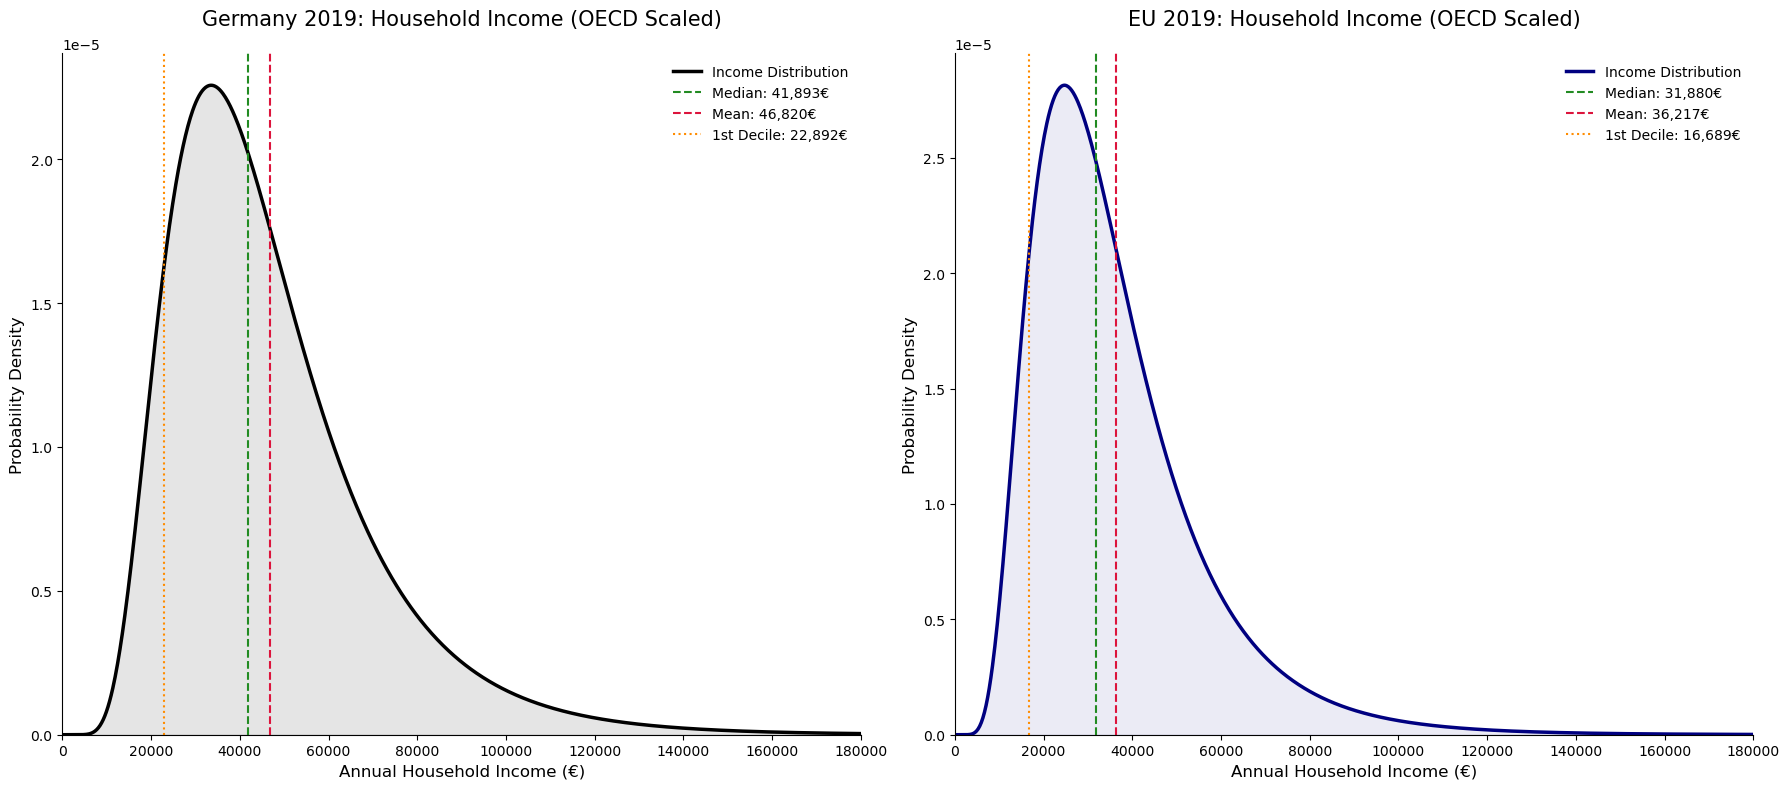

In [8]:
# --- 1. OECD Scale Configuration ---
# 1st Adult: 1.0, 2nd Adult: 0.5, 1 Child: 0.3
EQUIVALENCE_FACTOR = 1.8 

def get_hh_params(df_individual):
    df_hh = df_individual.copy()
    # Shift mu by the log of the equivalence factor
    df_hh['mu'] = df_individual['mu'] + np.log(EQUIVALENCE_FACTOR)
    df_hh['sigma'] = df_individual['sigma']
    return df_hh

# Transform dataframes
df_params_GER_hh = get_hh_params(df_params_GER)
df_params_EU_hh = get_hh_params(df_params_EU)

# --- 2. Plotting Logic ---
def get_pdf_data(df_params, year, x_range):
    row = df_params[df_params['Year'] == year].iloc[0]
    mu, sigma = row['mu'], row['sigma']
    pdf = lognorm.pdf(x_range, sigma, scale=np.exp(mu))
    
    median = np.exp(mu)
    mean = np.exp(mu + (sigma**2 / 2))
    first_decile = lognorm.ppf(0.10, sigma, scale=np.exp(mu))
    
    return pdf, median, mean, first_decile

# Requested range: 0 to 180,000
x_axis = np.linspace(0.1, 180000, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# --- Plot 1: Germany 2019 (Household) ---
pdf_g, med_g, avg_g, dec_g = get_pdf_data(df_params_GER_hh, 2019, x_axis)
ax1.plot(x_axis, pdf_g, color='black', lw=2.5, label='Income Distribution')
ax1.fill_between(x_axis, pdf_g, color='black', alpha=0.1) # Light fill
ax1.axvline(med_g, color='forestgreen', ls='--', label=f'Median: {med_g:,.0f}€')
ax1.axvline(avg_g, color='crimson', ls='--', label=f'Mean: {avg_g:,.0f}€')
ax1.axvline(dec_g, color='darkorange', ls=':', label=f'1st Decile: {dec_g:,.0f}€')
ax1.set_title("Germany 2019: Household Income (OECD Scaled)", fontsize=15, pad=20)

# --- Plot 2: EU 2019 (Household) ---
pdf_e, med_e, avg_e, dec_e = get_pdf_data(df_params_EU_hh, 2019, x_axis)
ax2.plot(x_axis, pdf_e, color='navy', lw=2.5, label='Income Distribution')
ax2.fill_between(x_axis, pdf_e, color='navy', alpha=0.08) # Light fill
ax2.axvline(med_e, color='forestgreen', ls='--', label=f'Median: {med_e:,.0f}€')
ax2.axvline(avg_e, color='crimson', ls='--', label=f'Mean: {avg_e:,.0f}€')
ax2.axvline(dec_e, color='darkorange', ls=':', label=f'1st Decile: {dec_e:,.0f}€')
ax2.set_title("EU 2019: Household Income (OECD Scaled)", fontsize=15, pad=20)

# --- Formatting for both plots ---
for ax in [ax1, ax2]:
    ax.set_xlabel("Annual Household Income (€)", fontsize=12)
    ax.set_ylabel("Probability Density", fontsize=12)
    ax.set_xlim(0, 180000)
    ax.set_ylim(bottom=0)
    ax.grid(False)
    ax.legend(frameon=False, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Graphs_output/Household_Income_Dists.png', dpi=300)
plt.show()

## Step 7: Conversion into Annual Household Energy Costs

This section translates standardized energy price data (EUR/kWh) into **actual annual expenditures for a representative household**. By applying defined consumption assumptions to the historical electricity and gas price series, a longitudinal estimate of the **total household energy bill** for both Germany and the EU can be constructed.

### 1. Description of the Processing Logic

The function `calculate_regional_costs` performs a multi-step transformation of the price data:

- **Data Integration:**  
  Electricity and gas price series are merged into a unified regional dataset, ensuring that both energy carriers can be evaluated within the same temporal framework.

- **Component Calculation:**  
  Annual costs are calculated separately for **electricity** and **gas** by multiplying the price per kWh with the assumed household consumption.  
  In addition, the calculation distinguishes between:
  - **Gross costs** (including taxes, levies, and policy charges)  
  - **Net costs** (excluding taxes and levies)

- **Tax Burden Extraction:**  
  By retaining both `WithTaxes` and `WithoutTaxes` variables, the pipeline prepares the dataset for a later decomposition of **policy-driven price components**.  
  This includes factors such as **VAT**, renewable energy surcharges (e.g., EEG-Umlage in Germany), and **CO₂ pricing mechanisms**.

### 2. Explanation of Assumptions

To ensure comparability across decades and regions, the model uses a **frozen consumption profile**. This is an important methodological decision.

- **Fixed Consumption Profile**

  The model assumes the following annual household demand:

  - **Electricity:** 4,000 kWh per year  
  - **Gas (heating):** 8,400 kWh per year  

  Gas consumption is calculated from a standardized heating demand:

  \[
  70 \, m^2 \times 120 \, kWh/m^2 = 8,400 \, kWh
  \]

  **Rationale:**  
  The goal is to simulate the energy costs faced by a **typical small family household** or better typical German households rather than allowing consumption changes to obscure price dynamics. Holding demand constant isolates the effect of **price developments and policy changes** over time. This approach is supported by the economic principle that **energy is a substantial good for living and largely non-substitutable**. 
  As a result, the **price elasticity of demand for household energy is very low**, approaching zero in some cases. 

- **Standardized Housing**

  A **70 m² apartment** is used as the reference dwelling.  
  This size represents a common apartment size for **small families or couples** in many European urban areas and provides a reasonable benchmark for household heating demand.

- **Gross Price Focus**

  For the subsequent socio-economic fairness analysis, the model prioritizes **Total_Energy_Cost_WithTaxes**.  
  This measure reflects the **actual liquidity burden** experienced by households, since taxes, levies, and policy surcharges are unavoidable components of the final energy bill.

### 3. Structural Output

The resulting datasets (`df_costs_GER` and `df_costs_EU`) represent the **cost component** of the analysis.

They provide the **numerator** for the final research metric.  
In the following step, these annual household energy costs will be divided by the **income levels of different income deciles** in order to compute the **Energy Burden Ratio**.

---

### Sources for Key Assumptions

The consumption and housing assumptions are based on commonly used benchmarks in European energy and housing statistics:

- https://www.buergergeld.org/news/buergergeld-so-hoch-darf-miete-wohnung-sein/​
- https://www.adac.de/rund-ums-haus/energie/spartipps/heizkosten-haushalt/​
- https://www.adac.de/rund-ums-haus/energie/spartipps/stromverbrauch-im-haushalt/

In [9]:
# --- 1. Constants & Assumptions (Stay the same) ---
HH_SIZE = 3
SQUARE_METERS = 70
GAS_KWH_PER_QM = 120
ANNUAL_GAS_CONSUMPTION = SQUARE_METERS * GAS_KWH_PER_QM  # 8,400 kWh
ANNUAL_ELEC_CONSUMPTION = 4000  # 4,000 kWh

def calculate_regional_costs(df_elec, df_gas, region_name):
    """
    Merges regional price data and calculates total annual costs based on consumption.
    """
    # Merge Elec and Gas prices on Year
    df_merged = pd.merge(df_elec, df_gas, on='Year', how='inner')
    
    # Identify price columns dynamically
    # Expecting names like: Elec_Germany_WithTaxes_perKWh
    col_elec_tax = f"Elec_{region_name}_WithTaxes_perKWh"
    col_elec_no_tax = f"Elec_{region_name}_WithoutTaxes_perKWh"
    col_gas_tax = f"Gas_{region_name}_WithTaxes_perKWh"
    col_gas_no_tax = f"Gas_{region_name}_WithoutTaxes_perKWh"
    
    # Initialize Cost DataFrame
    df_costs = pd.DataFrame({'Year': df_merged['Year']})
    
    # Calculate Electricity Costs
    df_costs['Electricity_Cost_WithTaxes'] = df_merged[col_elec_tax] * ANNUAL_ELEC_CONSUMPTION
    df_costs['Electricity_Cost_WithoutTaxes'] = df_merged[col_elec_no_tax] * ANNUAL_ELEC_CONSUMPTION
    
    # Calculate Gas Costs
    df_costs['Gas_Cost_WithTaxes'] = df_merged[col_gas_tax] * ANNUAL_GAS_CONSUMPTION
    df_costs['Gas_Cost_WithoutTaxes'] = df_merged[col_gas_no_tax] * ANNUAL_GAS_CONSUMPTION
    
    # Calculate Total Energy Costs
    df_costs['Total_Energy_Cost_WithTaxes'] = (df_costs['Electricity_Cost_WithTaxes'] + 
                                               df_costs['Gas_Cost_WithTaxes'])
    
    df_costs['Total_Energy_Cost_WithoutTaxes'] = (df_costs['Electricity_Cost_WithoutTaxes'] + 
                                                  df_costs['Gas_Cost_WithoutTaxes'])
    
    # Return rounded and clean result
    return df_costs.round(2).dropna().reset_index(drop=True)

# --- 2. Execute for both Regions ---

df_costs_GER = calculate_regional_costs(df_elec_GER, df_gas_GER, "Germany")
df_costs_EU  = calculate_regional_costs(df_elec_EU, df_gas_EU, "EU")

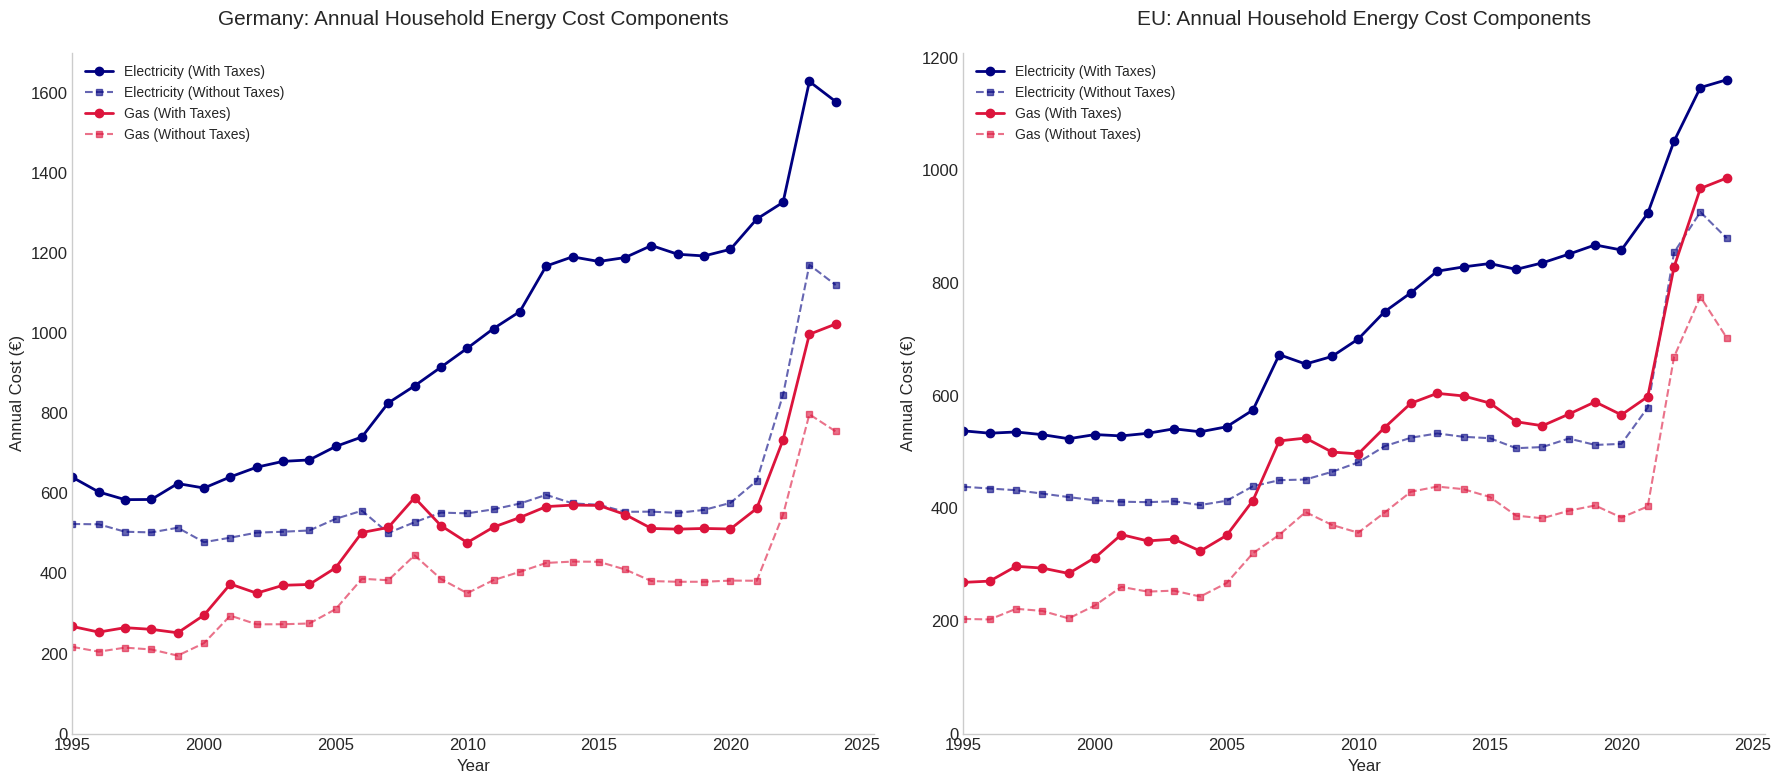

In [19]:
def plot_regional_energy_breakdown(df_costs, region_name, ax):
    """
    Plots annual electricity and gas costs with specific markers, 
    excluding total costs, with origin at the bottom-left corner.
    """
    # 1. Plot Electricity Costs (With and Without Taxes)
    ax.plot(df_costs['Year'], df_costs['Electricity_Cost_WithTaxes'], 
            marker='o', markersize=6, color='navy', lw=2, 
            label='Electricity (With Taxes)')
    
    ax.plot(df_costs['Year'], df_costs['Electricity_Cost_WithoutTaxes'], 
            marker='s', markersize=5, color='navy', lw=1.5, ls='--', alpha=0.6, 
            label='Electricity (Without Taxes)')
    
    # 2. Plot Gas Costs (With and Without Taxes)
    ax.plot(df_costs['Year'], df_costs['Gas_Cost_WithTaxes'], 
            marker='o', markersize=6, color='crimson', lw=2, 
            label='Gas (With Taxes)')
    
    ax.plot(df_costs['Year'], df_costs['Gas_Cost_WithoutTaxes'], 
            marker='s', markersize=5, color='crimson', lw=1.5, ls='--', alpha=0.6, 
            label='Gas (Without Taxes)')

    # --- Formatting ---
    ax.set_title(f"{region_name}: Annual Household Energy Cost Components", fontsize=15, pad=20)
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Annual Cost (€)", fontsize=12)
    
    # Ensure 0:0 is the bottom left corner
    # (Y-axis starts at 0, X-axis starts at the first year of data)
    ax.set_ylim(bottom=0)
    ax.set_xlim(left=df_costs['Year'].min())
    
    # Remove grid
    ax.grid(False)
    
    # Clean up visual style (remove top and right spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Legend in English with values
    ax.legend(frameon=False, loc='upper left', fontsize=10)

# Create a figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot for Germany
plot_regional_energy_breakdown(df_costs_GER, "Germany", ax1)

# Plot for EU
plot_regional_energy_breakdown(df_costs_EU, "EU", ax2)

plt.tight_layout()
plt.savefig('Graphs_output/energy_costs_breakdown.png', dpi=300)
plt.show()

## Step 7.1: Price Component Analysis (Tax Wedge & Market Volatility)

The plots above illustrate **annual energy expenditures for a standard household**, broken down by **energy carrier** and **tax status**. This analysis highlights the two primary drivers behind rising energy costs: **fiscal interventions (taxes and levies)** and **market shocks**.

### 1. The "Tax Gap" in Germany

A striking feature of the German energy market, compared to the EU average, is the **significant difference between net prices (dashed lines) and gross prices (solid lines)**.

- **Electricity:**  
  Since the early 2000s, the **“With Taxes”** trend has increasingly diverged from the **“Without Taxes”** baseline. In 1995, taxes contributed only a minor portion of the total bill; by 2020, they accounted for nearly **50% of household electricity costs**.  
  This reflects the financing of the **Energiewende** through levies such as the **EEG-Umlage**.

### 2. The 2021–2023 Energy Crisis (The "Double Spike")

Both electricity and gas charts show a **massive vertical escalation beginning in 2021**.

- **Gas Price Explosion:**  
  Gas prices remained relatively stable for nearly 25 years. The recent spike represents an **almost 300% increase in net prices within two years**.

- **The Shielding Effect:**  
  Electricity prices also spiked, but a **downward tick in 2024** (Germany) reflects **government interventions**, such as **EEG levy removal** and **price brakes**.  
  Gas costs, however, have settled at a **new, significantly higher plateau**, indicating persistent market pressure.

### 3. Germany vs. EU Benchmarking

- **Relative Cost Levels:**  
  German households face substantially higher absolute costs. For example, in 2015, a typical EU household paid around **€800** for electricity, whereas a German household paid over **€1,200**.

- **Volatility:**  
  The EU average shows a more **moderated response** to crises, such as the 2007/2008 financial shock.  
  In contrast, Germany experienced a **ratchet effect**—prices rose during crises but **never fully returned to pre-crisis levels**, even after market corrections.

### 4. Conclusion for Socio-Economic Fairness

These visualizations demonstrate that the **German Energy Transition is heavily “tax-driven”**.  
For households in the **first income decile**, the solid blue and red lines represent **mandatory expenditures** that have **tripled since 1995**, while their incomes have increased by only ~95% (see Step 5).  
This disparity underscores why the **Energy Burden Ratio** is becoming a **systemic threat to social stability**.

## Step 8: Quantifying Energy Poverty (The 10% Rule)

In this final analytical step, the **Energy Poverty Rate** is calculated. In economic research, a household is generally considered **energy-poor** if it must spend **more than 10% of its disposable income** to cover basic energy needs, such as heating and electricity.

### 1. Methodology: The Reverse CDF Approach

Rather than examining a fixed income group, the model determines the **Critical Income Threshold** required to remain below the 10% limit.

- **Calculation Example:**  
  If a household’s **annual energy bill** is €3,000, a **minimum disposable income of €30,000** is necessary to stay under the 10% threshold.

- **Probability Mapping:**  
  This critical income is then **fed into the lognormal cumulative distribution function (CDF)**. The output represents the **exact proportion of households whose income falls below this threshold**, i.e., those experiencing energy poverty.

### 2. Analytical Value: Taxes vs. Poverty

By performing the calculation for both **“With Taxes”** and **“Without Taxes”**, the model isolates the **social impact of fiscal policy**:

- The **difference between the two results** quantifies the share of the population **pushed into energy poverty specifically by state-mandated taxes and levies**, separate from pure market-driven price effects.

### 3. Structural Significance

This methodology offers several advantages over simpler approaches, such as focusing solely on the first income decile:

- **Accounts for Inflation and Wage Growth:**  
  If incomes increase faster than energy prices, the measured poverty rate decreases, even if absolute expenditures rise.

- **Captures Sensitivity of the Income Distribution:**  
  It reveals how fragile certain segments of the population are. Even a **small upward shift in energy prices** can push a substantial portion of households **below the critical threshold**, effectively “engulfing” them in energy poverty.

This approach therefore provides a **robust, dynamic measure** of energy poverty that is sensitive to both **income distribution** and **policy interventions**.

In [20]:
def calculate_energy_poverty_df(df_costs, df_params_hh):
    """
    Calculates the critical income threshold and the percentage of 
    households in energy poverty using the Log-Normal CDF.
    """
    # Merge the energy costs and household income parameters by Year
    df_merged = pd.merge(df_costs, df_params_hh, on='Year', how='inner')
    
    # 1. Define Critical Income (Threshold where energy cost is exactly 10% of income)
    # Calculation: Income = Cost / 0.10  => Income = Cost * 10
    df_merged['Critical_Income_WithTaxes'] = df_merged['Total_Energy_Cost_WithTaxes'] * 10
    df_merged['Critical_Income_WithoutTaxes'] = df_merged['Total_Energy_Cost_WithoutTaxes'] * 10
    
    # 2. Calculate Percentage of households below the Critical Income
    # We use the CDF of the log-normal distribution: lognorm.cdf(x, sigma, scale=exp(mu))
    df_merged['Percentage_EnergyPoverty_WithTaxes'] = df_merged.apply(
        lambda r: lognorm.cdf(r['Critical_Income_WithTaxes'], r['sigma'], scale=np.exp(r['mu'])) * 100, axis=1
    )
    
    df_merged['Percentage_EnergyPoverty_WithoutTaxes'] = df_merged.apply(
        lambda r: lognorm.cdf(r['Critical_Income_WithoutTaxes'], r['sigma'], scale=np.exp(r['mu'])) * 100, axis=1
    )
    
    # Select only the relevant columns for the final dataframe
    final_cols = [
        'Year', 
        'Critical_Income_WithTaxes', 
        'Critical_Income_WithoutTaxes', 
        'Percentage_EnergyPoverty_WithTaxes', 
        'Percentage_EnergyPoverty_WithoutTaxes'
    ]
    
    return df_merged[final_cols].round(2)

# --- Generate the Energy Poverty Dataframes ---
energy_pov_ger = calculate_energy_poverty_df(df_costs_GER, df_params_GER_hh)
energy_pov_eu = calculate_energy_poverty_df(df_costs_EU, df_params_EU_hh)

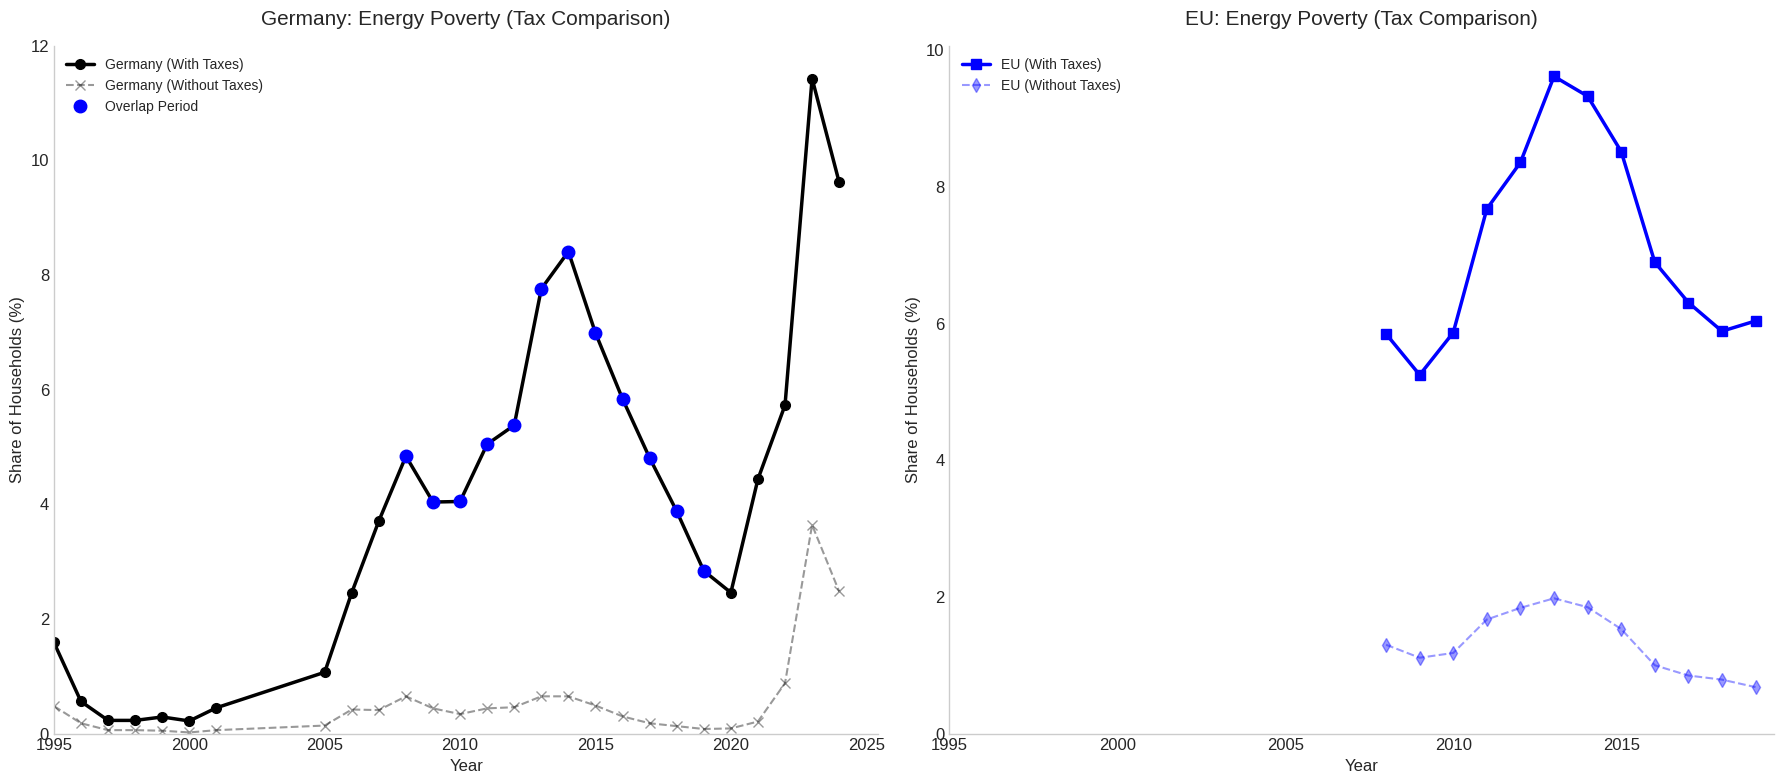

<Figure size 640x480 with 0 Axes>

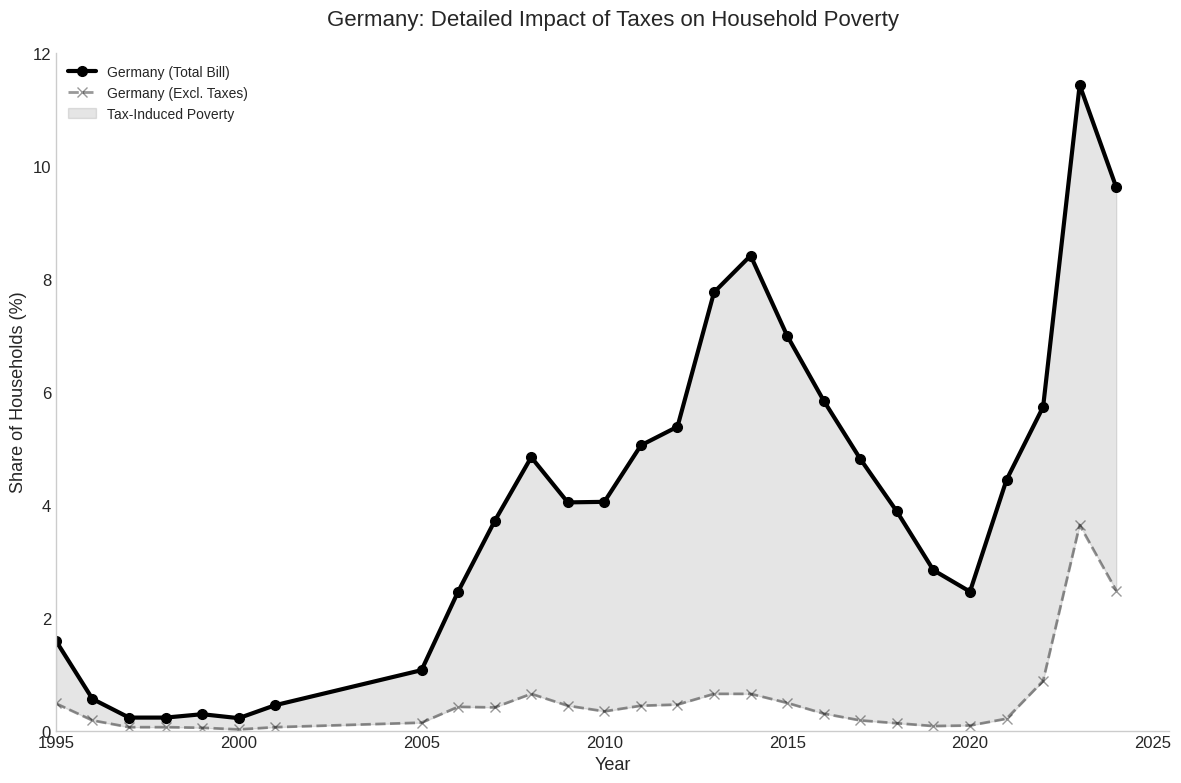

In [25]:
# --- Formatting Constants ---
GER_COLOR = 'black'
EU_COLOR = 'blue'
ALPHA_NO_TAX = 0.4
MARKER_SIZE = 7

# --- PLOT 1: Comparative Development (Germany vs EU) ---
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left Subplot: Germany
# Full line With Taxes
ax1.plot(energy_pov_ger['Year'], energy_pov_ger['Percentage_EnergyPoverty_WithTaxes'], 
         color=GER_COLOR, lw=2.5, marker='o', ms=MARKER_SIZE, label='Germany (With Taxes)')
# Full line Without Taxes (Alpha)
ax1.plot(energy_pov_ger['Year'], energy_pov_ger['Percentage_EnergyPoverty_WithoutTaxes'], 
         color=GER_COLOR, lw=1.5, ls='--', marker='x', ms=MARKER_SIZE, alpha=ALPHA_NO_TAX, label='Germany (Without Taxes)')

# Overlap Highlight: Blue marker/line where EU and GER intersect
overlap_years = energy_pov_ger['Year'][energy_pov_ger['Year'].isin(energy_pov_eu['Year'])]
overlap_data = energy_pov_ger[energy_pov_ger['Year'].isin(overlap_years)]
ax1.plot(overlap_data['Year'], overlap_data['Percentage_EnergyPoverty_WithTaxes'], 
         color=EU_COLOR, lw=0, marker='o', ms=MARKER_SIZE + 2, label='Overlap Period')

ax1.set_title("Germany: Energy Poverty (Tax Comparison)", fontsize=15, pad=15)

# Right Subplot: EU Development
ax2.plot(energy_pov_eu['Year'], energy_pov_eu['Percentage_EnergyPoverty_WithTaxes'], 
         color=EU_COLOR, lw=2.5, marker='s', ms=MARKER_SIZE, label='EU (With Taxes)')
ax2.plot(energy_pov_eu['Year'], energy_pov_eu['Percentage_EnergyPoverty_WithoutTaxes'], 
         color=EU_COLOR, lw=1.5, ls='--', marker='d', ms=MARKER_SIZE, alpha=ALPHA_NO_TAX, label='EU (Without Taxes)')

ax2.set_title("EU: Energy Poverty (Tax Comparison)", fontsize=15, pad=15)

# Formatting for Comparison Plot
for ax in [ax1, ax2]:
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Share of Households (%)", fontsize=12)
    ax.set_ylim(bottom=0)
    ax.set_xlim(left=min(energy_pov_ger['Year'].min(), energy_pov_eu['Year'].min()))
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()
plt.savefig('Graphs_output/comparative_energy_poverty.png', dpi=300)

# --- PLOT 2: Germany Only (Detailed Tax Impact) ---
plt.figure(figsize=(12, 8))
ax_ger = plt.gca()

ax_ger.plot(energy_pov_ger['Year'], energy_pov_ger['Percentage_EnergyPoverty_WithTaxes'], 
            color=GER_COLOR, lw=3, marker='o', ms=MARKER_SIZE, label='Germany (Total Bill)')
ax_ger.plot(energy_pov_ger['Year'], energy_pov_ger['Percentage_EnergyPoverty_WithoutTaxes'], 
            color=GER_COLOR, lw=2, ls='--', marker='x', ms=MARKER_SIZE, alpha=ALPHA_NO_TAX, label='Germany (Excl. Taxes)')

# Fill the area to emphasize the government's share in poverty rates
ax_ger.fill_between(energy_pov_ger['Year'], 
                    energy_pov_ger['Percentage_EnergyPoverty_WithoutTaxes'], 
                    energy_pov_ger['Percentage_EnergyPoverty_WithTaxes'], 
                    color=GER_COLOR, alpha=0.1, label='Tax-Induced Poverty')

ax_ger.set_title("Germany: Detailed Impact of Taxes on Household Poverty", fontsize=16, pad=20)
ax_ger.set_xlabel("Year", fontsize=13)
ax_ger.set_ylabel("Share of Households (%)", fontsize=13)
ax_ger.set_xlim(left=energy_pov_ger['Year'].min())
ax_ger.set_ylim(bottom=0)
ax_ger.grid(False)
ax_ger.spines['top'].set_visible(False)
ax_ger.spines['right'].set_visible(False)
ax_ger.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig('Graphs_output/detailed_energy_poverty.png', dpi=300)
plt.show()

## Step 10: Final Analysis – The Social Cost of the Energy Transition

The visualizations consolidate all previous analytical steps—**income distribution, energy price evolution, and consumption assumptions**—into a comprehensive view of the **socio-economic burden** imposed by the energy transition.

### 1. The "Tax-Induced Poverty" Effect (Germany)

The detailed German visualization highlights a **substantial gap** between energy poverty driven by **market prices alone** (dashed line) and the **actual burden including taxes and levies** (solid black line).

- **Tax-Induced Poverty:**  
  The gray shaded area demonstrates that, **without taxes and levies**, energy poverty in Germany would have remained **negligible (near 0%)** for decades.

- **The Turning Point:**  
  Starting in **2005**, the proportion of households pushed into energy poverty by **gross energy costs** (per the 10% rule) increased sharply, reaching an **initial peak of over 8% by 2014**.

- **Interpretation:**  
  Financing the energy transition through electricity prices—via levies such as the **EEG-Umlage**—**disproportionately affected low-income households (P10)**. These households were forced to allocate a **much larger share of their disposable income** to fixed levies compared to higher-income groups.

### 2. The 2021–2024 Energy Crisis

The recent escalation represents an **unprecedented spike** in energy poverty.

- **Record Highs:**  
  In Germany, the **energy poverty rate** reached over **11% in 2023**, a historic maximum.

- **Persistent Levels:**  
  Although prices fell slightly in 2024, the rate remains near **10%**, almost **ten times the level observed two decades earlier**.

- **Key Observations:**  
  The modest decline in the solid black line reflects **policy interventions**, including the **abolition of the EEG levy** and other **government relief packages** (price brakes).  
  However, **“net poverty”**—excluding taxes—remains elevated relative to historical norms, reflecting the **surge in wholesale and procurement costs**.

### 3. Germany vs. EU: A Comparison

- **Sensitivity:**  
  In the EU (blue charts), the gap between **gross and net household burden** exists but is **far less pronounced** than in Germany.

- **Methodological Consistency:**  
  The overlap period (highlighted with **blue dots** in the German graph) confirms the **harmonization process performed in Step 2**.  
  Despite Eurostat’s **2007 methodological shift**, the observed trends are **robust and comparable** across regions.

## Step 11: Fiscal Impact – The Cost of Eradicating Energy Poverty

This step transitions from identifying the problem to **proposing a quantitative fiscal solution**. By calculating the **“Mean Gap”**, the model determines the **exact financial assistance** required to ensure that every affected household stays below the 10% energy burden threshold.

### 1. The "Mean Gap" Methodology

Rather than applying a flat subsidy, the model uses a **calculus-based approach** (quadrature integration) to determine the **precise support needed for each household**.

- **The Logic:**  
  For every household below the energy poverty line, the state provides a subsidy exactly equal to:  

  \[
  \text{Subsidy} = \text{ActualCost} - (0.10 \times \text{HouseholdIncome})
  \]

- **Mean Refund:**  
  This represents the **average amount each affected household would receive**.  
  In 2023/2024, this amount constitutes a **critical liquidity injection** for the bottom income deciles, mitigating immediate financial strain.

### 2. Fiscal Trends: The Price of Social Stability

The visualizations convey two essential perspectives on the **German state budget**:

- **Figure 1: Mean Refund per Household**  
  - This line indicates the **intensity of energy poverty**.  
  - A rising trend signals that **not only are more households affected**, but **those already in poverty are experiencing deeper financial stress**.  
  - The gap between solid and dashed lines highlights the portion of required assistance that **simply offsets taxes previously collected on energy bills**.

- **Figure 2: Total Annual State Budget (The “State Bill”)**  
  - This bar chart quantifies the **aggregate fiscal commitment in billions of euros**.  
  - **2023 Spike:** The energy crisis triggers a **dramatic surge in the state bill**, representing the theoretical cost of implementing a **“Social Energy Shield.”**  
  - **Gross vs. Net Comparison:** By contrasting the dark blue (Gross) and light blue (Net) bars, the model illustrates how much **cheaper the solution would be** if energy taxes for low-income households were **waived upfront**, rather than collected and later refunded via subsidies.

This step therefore provides a **clear, data-driven estimate of the fiscal resources** needed to eradicate energy poverty while highlighting the efficiency of **tax policy adjustments versus direct transfers**.

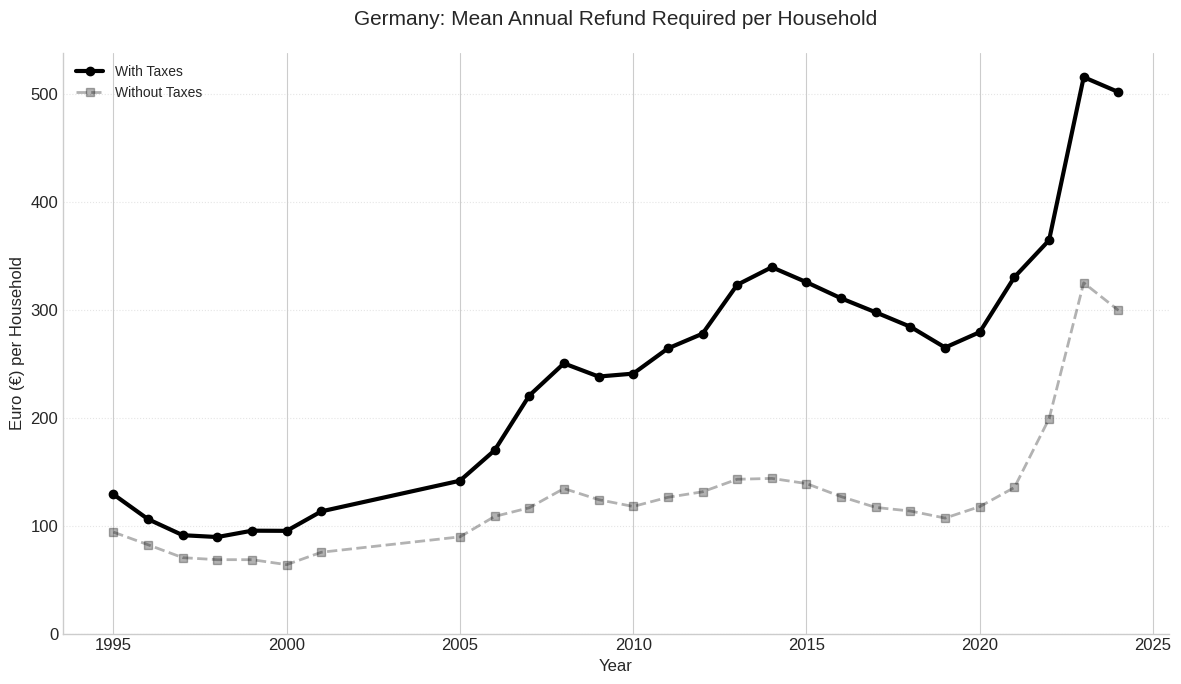

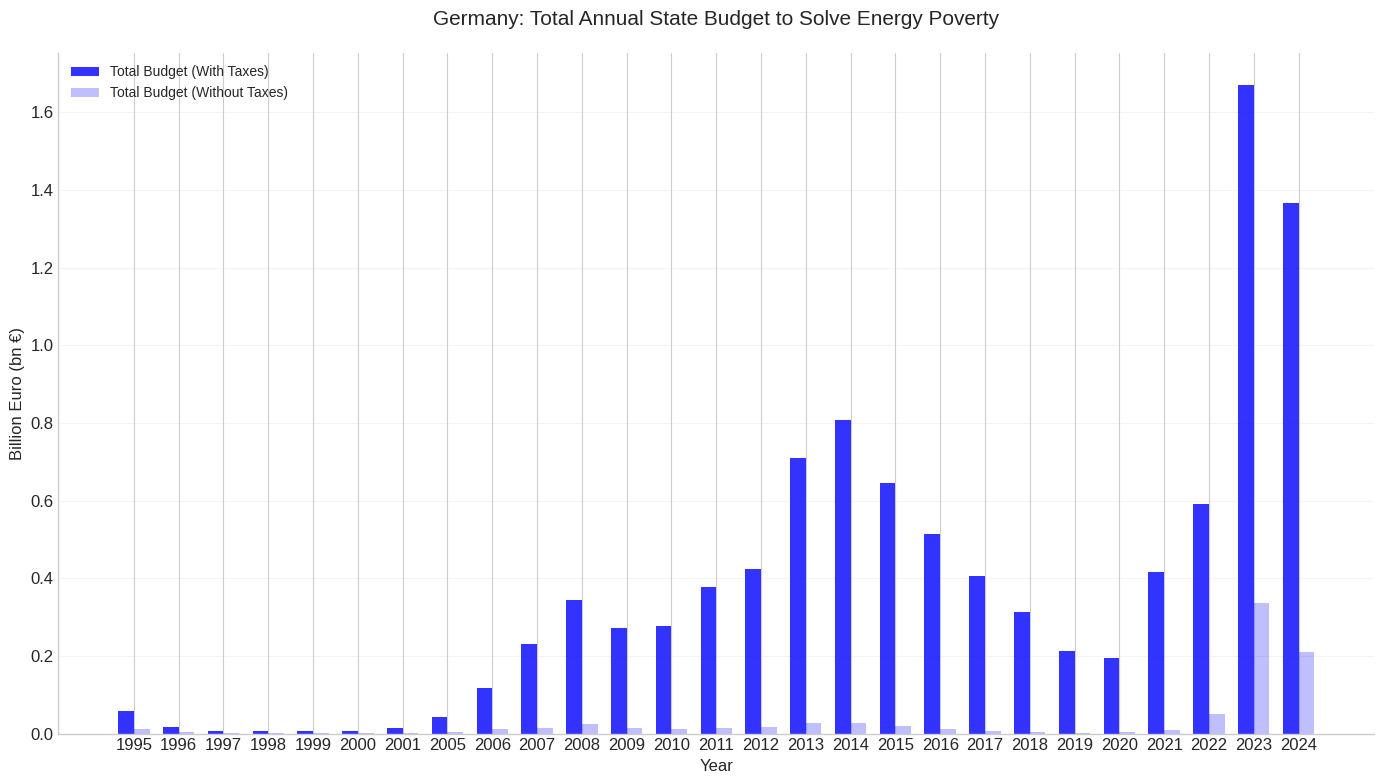

In [27]:
# --- 1. Constants ---
# Using your 85M / 3 approximation (~28.33 Million Households)
TOTAL_GER_HOUSEHOLDS = 85_000_000 / 3 

def get_mean_gap(row, tax_type='WithTaxes'):
    """ Calculates the exact mean gap using the integral of (Cost - 10% Income) """
    mu = row['mu']
    sigma = row['sigma']
    cost = row[f'Total_Energy_Cost_{tax_type}']
    threshold = cost * 10
    
    # The Gap Function: (Cost - 10% of Income) * PDF(Income)
    def gap_func(x):
        return (cost - 0.10 * x) * lognorm.pdf(x, sigma, scale=np.exp(mu))
    
    # Integrate from 0 to the critical threshold
    total_gap_integral, _ = quad(gap_func, 0, threshold)
    
    # Divide by the share of people in poverty to get the MEAN refund per affected HH
    poverty_share = lognorm.cdf(threshold, sigma, scale=np.exp(mu))
    
    return total_gap_integral / poverty_share if poverty_share > 0 else 0

# --- 2. Processing Data ---
# Merge costs and income params
df_final = pd.merge(df_costs_GER, df_params_GER_hh, on='Year')

# Calculate Mean Refund per Year
df_final['Mean_Refund_WithTax'] = df_final.apply(lambda r: get_mean_gap(r, 'WithTaxes'), axis=1)
df_final['Mean_Refund_NoTax'] = df_final.apply(lambda r: get_mean_gap(r, 'WithoutTaxes'), axis=1)

# Calculate Total State Cost in Billions
# Total Cost = Mean Refund * (Poverty Percentage / 100) * Total Households
def calc_total_bill(row, tax_type='WithTax'):
    # Determine which cost and threshold to use for the share
    cost_col = 'Total_Energy_Cost_WithTaxes' if tax_type == 'WithTax' else 'Total_Energy_Cost_WithoutTaxes'
    threshold = row[cost_col] * 10
    share = lognorm.cdf(threshold, row['sigma'], scale=np.exp(row['mu']))
    
    return (row[f'Mean_Refund_{tax_type}'] * share * TOTAL_GER_HOUSEHOLDS) / 1e9

df_final['Total_State_Bill_WithTax'] = df_final.apply(lambda r: calc_total_bill(r, 'WithTax'), axis=1)
df_final['Total_State_Bill_NoTax'] = df_final.apply(lambda r: calc_total_bill(r, 'NoTax'), axis=1)

# --- 3. Plotting ---

# --- FIGURE 1: Mean Refund per Household (Line Plot) ---
plt.figure(figsize=(12, 7))
ax1 = plt.gca()

# Germany Color Scheme (Black)
ax1.plot(df_final['Year'], df_final['Mean_Refund_WithTax'], 
         marker='o', color='black', lw=3, label='With Taxes')
ax1.plot(df_final['Year'], df_final['Mean_Refund_NoTax'], 
         marker='s', color='black', lw=2, ls='--', alpha=0.3, label='Without Taxes')

ax1.set_title("Germany: Mean Annual Refund Required per Household", fontsize=15, pad=20)
ax1.set_ylabel("Euro (€) per Household", fontsize=12)
ax1.set_xlabel("Year", fontsize=12)

# Styling
ax1.set_ylim(bottom=0)
ax1.grid(axis='y', linestyle=':', alpha=0.5) # Light trace lines for readability
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig('Graphs_output/mean_refund_per_household.png', dpi=300)
plt.show()

# --- FIGURE 2: Total State Cost (Bar Plot) ---
plt.figure(figsize=(14, 8))
ax2 = plt.gca()

x_indices = np.arange(len(df_final['Year']))
bar_width = 0.35

# State Budget Color Scheme (Blue)
# No text labels on bars as requested - rely on Y-axis
ax2.bar(x_indices - bar_width/2, df_final['Total_State_Bill_WithTax'], 
        width=bar_width, color='blue', alpha=0.8, label='Total Budget (With Taxes)')

ax2.bar(x_indices + bar_width/2, df_final['Total_State_Bill_NoTax'], 
        width=bar_width, color='blue', alpha=0.25, label='Total Budget (Without Taxes)')

# Axis Formatting
ax2.set_title("Germany: Total Annual State Budget to Solve Energy Poverty", fontsize=15, pad=20)
ax2.set_ylabel("Billion Euro (bn €)", fontsize=12)
ax2.set_xticks(x_indices)
ax2.set_xticklabels(df_final['Year'])
ax2.set_xlabel("Year", fontsize=12)

# Clean Origin and Grid
ax2.set_ylim(bottom=0)
ax2.grid(axis='y', linestyle='-', alpha=0.2) # Horizontal lines to help reading values
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(frameon=False, loc='upper left')

# Optimization for "Hoverability" in interactive backends
# In Jupyter/Spyder, this allows the coordinates to show in the bottom right 
# when you move your mouse over the bars.
plt.tight_layout()
plt.savefig('Graphs_output/figure5_refund_model.png', dpi=300)
plt.show()

## Final Review: The Socio-Economic Cost of the Energy Transition

This analysis provides a **data-driven conclusion** to the research question:  
**How has the German energy transition influenced energy poverty and fiscal equity over the last 30 years?**  
By harmonizing decades of Eurostat data and simulating household income distributions using a **lognormal model**, the study reaches several definitive conclusions.

### 1. Structural Inequity in Income Growth

The foundation of the current energy poverty crisis lies in **divergent income trends**:

- **Median vs. Low-Income Growth:**  
  Between 1995 and 2024, the German **median household income** increased by **104.7%**, while the income of the **lowest 10% (P10)** grew by only **95.0%**.  

- **Interpretation:**  
  Low-income households therefore have a **smaller financial buffer** to absorb rising costs of essential goods such as electricity and gas, making them disproportionately vulnerable to energy price shocks.

### 2. The "Tax-Induced Poverty" Trap

The research demonstrates that energy poverty in Germany is largely a **structural issue**, driven more by **fiscal policy** than by pure market fluctuations:

- **Policy Wedge:**  
  Without taxes and levies, energy poverty would have remained **near 0%** throughout most of the study period.  

- **Peak Burden:**  
  Including taxes, the energy poverty rate **peaked at over 11%** during the 2023 energy crisis.  

- **Regressive Financing:**  
  Consumption-based levies, such as the **EEG-Umlage**, act as a **regressive tax**, disproportionately affecting households that allocate a larger share of their income to basic energy needs.

### 3. Fiscal Resolution Costs

Simulation of a **targeted “State Refund” system** quantifies the **budget required to eradicate energy poverty**:

- **Household Level:**  
  In 2023, an **average affected household** would have required a refund of approximately **€500** to remain below the 10% energy burden threshold.  

- **Macro Level:**  
  The **total annual state budget** needed peaked at roughly **€1.6 billion**.  

- **Policy Efficiency:**  
  Waiving energy taxes for low-income households is **far more efficient** than collecting taxes and redistributing them through social benefits.  
  The **“net” cost** of eliminating energy poverty is only a **fraction of the “gross” cost** under the current tax-then-refund system.

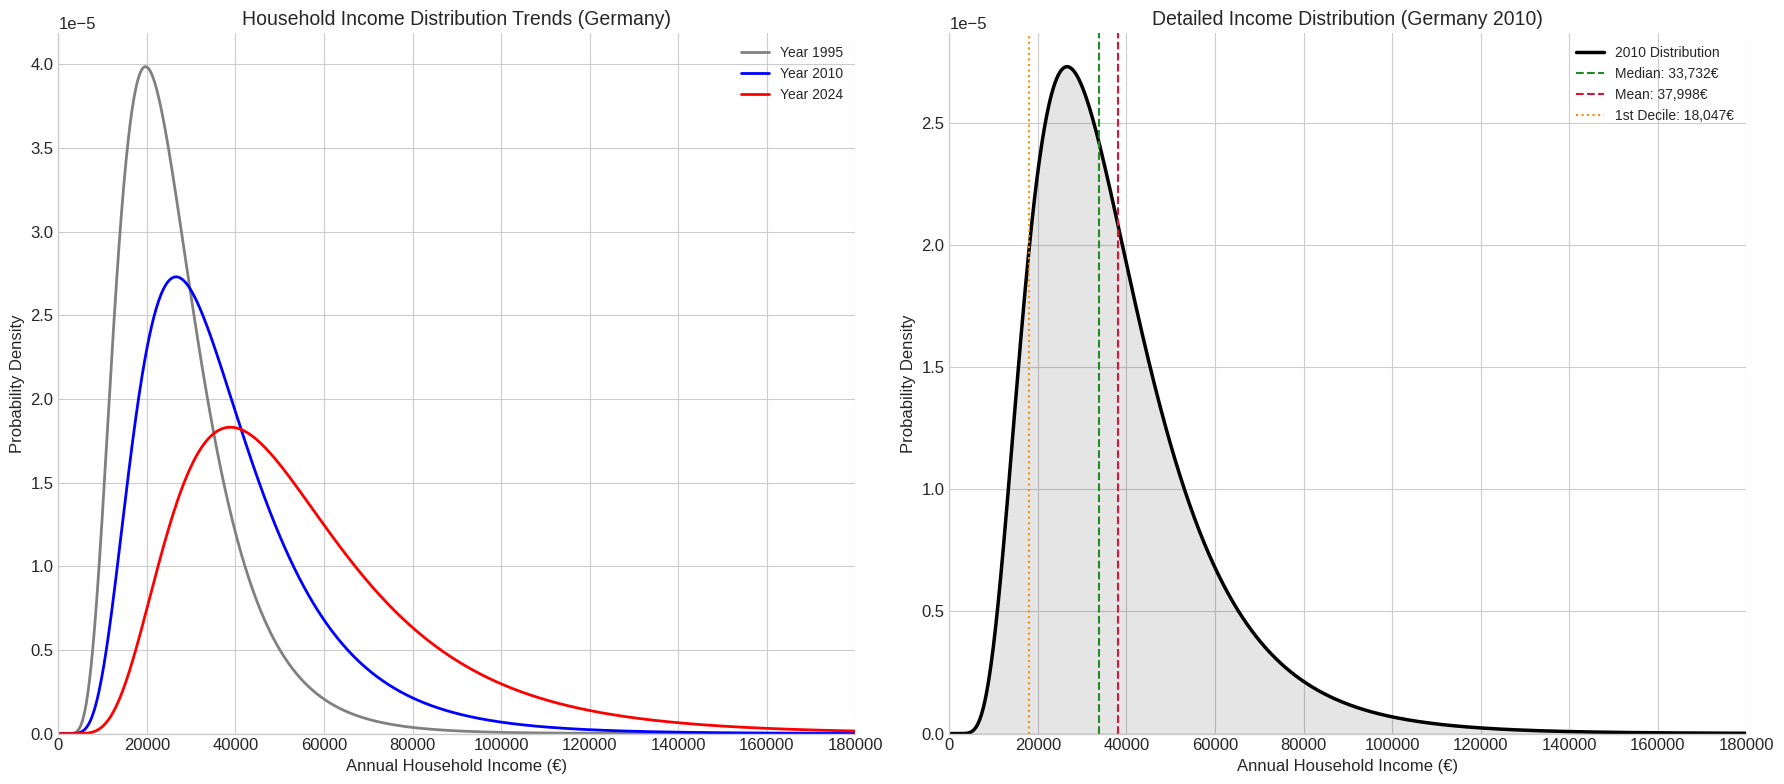

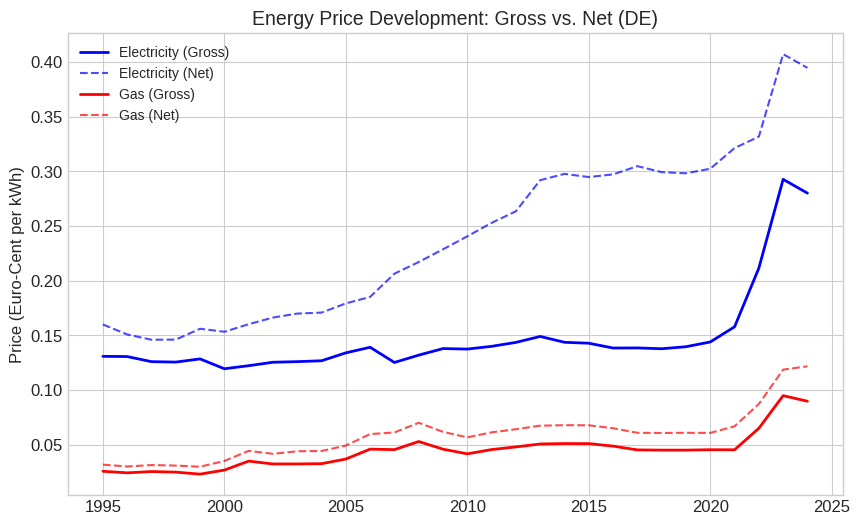

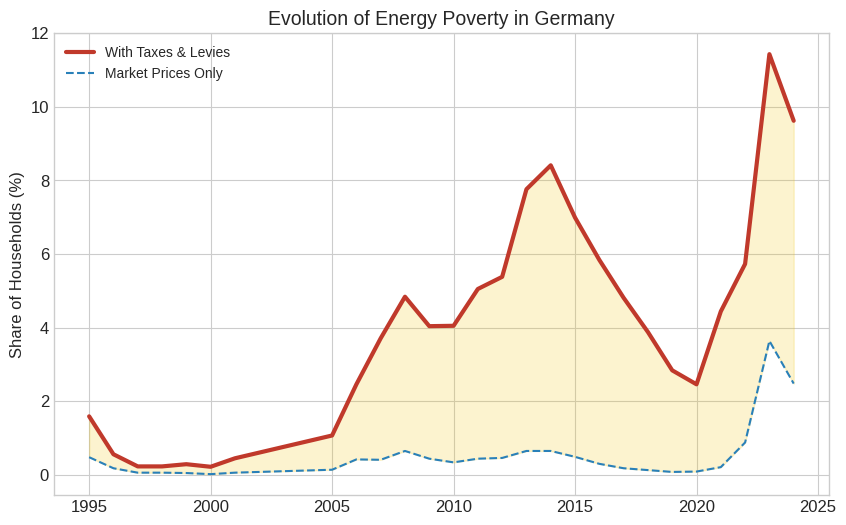

In [33]:
# Create output directory
output_dir = 'Graphs_output'

# Globales Styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'savefig.dpi': 300
})

# --- 1. Energy Consumption and Renewable Share (DE) ---
ax1.plot(df_energy_final['Year'], df_energy_final['All Energy Sources'] / 1_000_000_000, color='#2c3e50', linewidth=2.5)
ax1.set_title('Total Household Energy Consumption (DE)')
ax1.set_ylabel('Consumption (TWh)')
ax1.set_xlabel('Year')

ax2.plot(df_energy_final['Year'], df_energy_final['Renewable_Share'] * 100, color='#27ae60', linewidth=2.5)
ax2.set_title('Share of Renewable Energy (DE)')
ax2.set_ylabel('Share (%)')
ax2.set_xlabel('Year')

fig1.tight_layout()
fig1.savefig(output_dir+'/figure1_energy_mix.png')

# --- 2. Income Distribution (Lognormal Curves) ---
# Helper Function for Distribution Stats (Probability Density Function)
def get_pdf_data(df_params, year, x_range):
    # Extracts mu and sigma for the specific year
    row = df_params[df_params['Year'] == year].iloc[0]
    mu, sigma = row['mu'], row['sigma']
    
    # Calculate PDF, Median, Mean and 1st Decile
    pdf = lognorm.pdf(x_range, sigma, scale=np.exp(mu))
    median = np.exp(mu)
    mean = np.exp(mu + (sigma**2 / 2))
    first_decile = lognorm.ppf(0.10, sigma, scale=np.exp(mu))
    
    return pdf, median, mean, first_decile

# Styling Constants
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12})
GER_COLOR = 'black'
ELEC_COLOR = 'blue'
GAS_COLOR = 'red'

# --- FIGURE 2: Income Distribution (Trends & 2002 Detail) ---
x_axis = np.linspace(0.1, 180000, 1000) # Range for annual income
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left: Trend curves for 1995, 2010, 2024
for year, color in zip([1995, 2010, 2024], ['gray', 'blue', 'red']):
    pdf, _, _, _ = get_pdf_data(df_params_GER_hh, year, x_axis)
    ax1.plot(x_axis, pdf, color=color, lw=2, label=f'Year {year}')
ax1.set_title("Household Income Distribution Trends (Germany)")

# Right: 2010 Detailed with Statistics
pdf_10, med_10, avg_10, dec_10 = get_pdf_data(df_params_GER_hh, 2010, x_axis)
ax2.plot(x_axis, pdf_10, color='black', lw=2.5, label='2010 Distribution')
ax2.fill_between(x_axis, pdf_10, color='black', alpha=0.1)
ax2.axvline(med_10, color='forestgreen', ls='--', label=f'Median: {med_10:,.0f}€')
ax2.axvline(avg_10, color='crimson', ls='--', label=f'Mean: {avg_10:,.0f}€')
ax2.axvline(dec_10, color='darkorange', ls=':', label=f'1st Decile: {dec_10:,.0f}€')
ax2.set_title("Detailed Income Distribution (Germany 2010)")

for ax in [ax1, ax2]:
    ax.set_xlabel("Annual Household Income (€)")
    ax.set_ylabel("Probability Density")
    ax.set_xlim(0, 180000)
    ax.set_ylim(bottom=0)
    ax.legend(frameon=False, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(output_dir + '/figure2_income_distribution.png', dpi=300)

# --- 3. Prices Gross vs Net (DE) ---
# Nutzt 'df_prices_germany'
plt.figure(figsize=(10, 6))
plt.plot(df_elec_GER['Year'], df_elec_GER['Elec_Germany_WithoutTaxes_perKWh'], 'b-', label='Electricity (Gross)', linewidth=2)
plt.plot(df_elec_GER['Year'], df_elec_GER['Elec_Germany_WithTaxes_perKWh'], 'b--', label='Electricity (Net)', alpha=0.7)
plt.plot(df_gas_GER['Year'], df_gas_GER['Gas_Germany_WithoutTaxes_perKWh'], 'r-', label='Gas (Gross)', linewidth=2)
plt.plot(df_gas_GER['Year'], df_gas_GER['Gas_Germany_WithTaxes_perKWh'], 'r--', label='Gas (Net)', alpha=0.7)
plt.title('Energy Price Development: Gross vs. Net (DE)')
plt.ylabel('Price (Euro-Cent per kWh)')
plt.legend()
plt.savefig(output_dir+'/figure3_tax_wedge.png')

# --- 4. Energy Poverty Rates (DE) ---
# Nutzt 'df_poverty_results'
plt.figure(figsize=(10, 6))
plt.plot(energy_pov_ger['Year'], energy_pov_ger['Percentage_EnergyPoverty_WithTaxes'], color='#c0392b', label='With Taxes & Levies', linewidth=3)
plt.plot(energy_pov_ger['Year'], energy_pov_ger['Percentage_EnergyPoverty_WithoutTaxes'], color='#2980b9', linestyle='--', label='Market Prices Only')
plt.fill_between(energy_pov_ger['Year'], energy_pov_ger['Percentage_EnergyPoverty_WithoutTaxes'], energy_pov_ger['Percentage_EnergyPoverty_WithTaxes'], color='#f1c40f', alpha=0.2)
plt.title('Evolution of Energy Poverty in Germany')
plt.ylabel('Share of Households (%)')
plt.legend()
plt.savefig(output_dir+'/figure4_energy_poverty.png')